In [1]:
import scvi
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 

/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sc.logging.print_versions()




-----
anndata     0.10.7
scanpy      1.10.1
-----
PIL                 10.3.0
absl                NA
asttokens           NA
attr                23.2.0
chex                0.1.86
comm                0.2.2
contextlib2         NA
cycler              0.12.1
cython_runtime      NA
dateutil            2.9.0.post0
debugpy             1.8.1
decorator           5.1.1
docrep              0.3.2
etils               1.9.1
executing           2.0.1
filelock            3.14.0
flax                0.8.4
fsspec              2024.6.0
h5py                3.11.0
igraph              0.11.8
ipykernel           6.29.4
jax                 0.4.35
jax_cuda12_plugin   NA
jax_plugins         NA
jaxlib              0.4.34
jedi                0.19.1
joblib              1.4.2
kiwisolver          1.4.5
legacy_api_wrap     NA
leidenalg           0.10.2
lightning           2.1.4
lightning_utilities 0.11.2
llvmlite            0.43.0
matplotlib          3.9.0
ml_collections      NA
ml_dtypes           0.4.0
mpl_toolkits   


### Assumes GPU available for scanVI (but could do pre-processing (highest mem requirement}), then use smaller resources with GPU for integration)

# Load reference map (~60gb)

In [3]:
"""
Here we assume scRNA-seq data is being used. With Xenium data, higher-resolution annotations seemed to be achieved by mapping to scRNA-seq data also.

# dataset is available here (choose scRNA_seq)
https://cellatlas.io/studies/spatial-skin-atlas

"""

'\nHere we assume scRNA-seq data is being used. With Xenium data, higher-resolution annotations seemed to be achieved by mapping to scRNA-seq data also.\n\n# dataset is available here (choose scRNA_seq)\nhttps://cellatlas.io/studies/spatial-skin-atlas\n\n'

In [4]:
"""
PUT THE PATH TO THE REFERENCE ADATA HERE, AND THEN LOAD
"""
adata_reference_path = '/nfs/team298/ls34/adult_skin/final_adatas/adata_scrna_webportal.h5ad'
adata=sc.read_h5ad(adata_reference_path)
try:
    del(adata.obsm)
    del(adata.obsp)
except:
    1
adata

AnnData object with n_obs × n_vars = 1730938 × 32732
    obs: 'sample_id', 'barcode', 'GSE', 'Site_status', 'Patient_status', 'dataset_id', 'lvl5_annotation', 'lvl4_annotation', 'lvl0', 'Site_status_simple', 'lvl1_new', 'Site_status2'
    uns: 'QC_mid_colors', 'leiden_res0.1', 'leiden_res0.1_colors', 'lvl0_colors', 'lvl4_annotation_colors', 'lvl5_annotation_colors', 'neighbor_20', 't_colors', 'umap'

# Prepare your data

In [5]:
"""
### add path to your adata here. 

"""
adata_tomap_path = "/lustre/scratch124/cellgen/haniffa/projects/beacon/nobackup_output/model_scanvi_v4ALLn_atlas_time_final_firstrun_1947_5epochs/adata_empd.h5ad"
adata_tomap=sc.read_h5ad(adata_tomap_path)
try:
    del(adata_tomap.obsm)
    del(adata_tomap.obsp)
except:
    1
adata_tomap

AnnData object with n_obs × n_vars = 7607 × 37267
    obs: 'sample_id', 'barcode', 'barcode+sample', 'dataset_id', 'GSE', 'Site_status', 'Patient_status', 'DonorID', 'Location', 'n_genes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'orig.nb', 'batch', 'Tissue', 'calls', 'percent.mt', 'QC', 'RNA_snn_res.0.5', 'seurat_clusters', 'seurat_clusters_harmony', 'age', 'sex', 'race', 'bodysite', 'celltype', 'lvl5_annotation', 'Age', 'Sex', 'lvl3_annotation', 'lvl0_annotation', 'OriginalAnnotation', 'provisional_celltypes', 'lvl5_annotation_new3', 'original_annotation', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'QC_hi', 'QC_mid', 'QC_lo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mt', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'sample_barcode', 'doublet_score'

In [6]:
"""
check counts data
"""
try:
    print(adata_tomap.X[:10,:10].A)
except:
    print(adata_tomap.X[:10,:10].todense())
print("check this is counts data")

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
check this is counts data


In [7]:
"""
Data to map is unlabelled (labels trasnferred from skin atlas)
"""
adata_tomap.obs["lvl5_annotation"] = "New/unlabelled/excluded"

In [8]:
"""
SET SAMPLE ID COLUMN FROM YOUR DATA
"""
#adata_tomap.obs["sample_id"] = adata_tomap.obs["orig.ident"]
#adata_tomap.obs["sample_id"].value_counts()


'\nSET SAMPLE ID COLUMN FROM YOUR DATA\n'

In [9]:
assert "sample_id" in adata_tomap.obs.columns, "ERROR: adata.obs does not contain 'sample_id'"


In [10]:
"""
SET PATH TO SAVE OUTPUT AND NAME OF DATASET
"""
# base dir where model output saves + preintegration adata saves
BASE = '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output/'
DATASET="TUTORIAL_EMPD"
adata_path =  BASE + f'adata_{DATASET}_and_SpatialSkinAtlas_preintegration.h5ad'


In [11]:
"""
These parameters i've used quite consistently for scrna. 
For xenium mapping (or if data not clean (junk populations)), i would change to 10 latent and 1 layer, and reduced HVG number

# if mapping xenium, consider adding "technology" as a categorical covariate (i.e. xenium vs scrna)
"""

N_LATENT=30
N_LAYERS=2
NEIGHBOR=20
MIN_DIST=0.1
HVG_BATCH_KEY = "sample_id"
HVG_NUMBER = 2000
run_scanvi=True # if false, will run scvi
SCANVI_LABELS_KEY="lvl5_annotation" # this is where cell type annotations are stored for SpatialSkinAtlas. We consider the new data to be unlabelled (hence adata_tomap.obs["lvl5_annotation"] = "New/unlabelled/excluded" )
SCANVI_UNLABELLED="New/unlabelled/excluded"
BATCH_SIZE=512

MAX_EPOCHS=10
EARLY_STOPPING_PATIENCE=4

CAT_COVS=[]


In [ ]:
1

In [12]:
"""
IF XENIUM DATA, REDUCE REFERENCE ADATA DOWN TO GENES ONLY FOUND IN XENIUM DATA
"""

# xenium_genes = adata_tomap.var_names
# common_genes = [g for g in xenium_genes if g in adata.var_names]

# adata = adata[:, common_genes].copy()      
# adata_tomap = adata_tomap[:, common_genes].copy()     



'\nIF XENIUM DATA, REDUCE REFERENCE ADATA DOWN TO GENES ONLY FOUND IN XENIUM DATA\n'

# Merge datasets (used 173gb with EMPD data) - max memory usage in notebook at this step

In [ ]:
adata = ad.concat([adata, adata_tomap], label="Mapping_status", keys=["SpatialSkinAtlas", DATASET], 
                  join='inner')
del(adata_tomap)
import gc
gc.collect()
    


In [ ]:
"""
We now save this data as it has all genes + counts, and we will re-load after selecting HVGs (which requires normalisation) so that we have count data again as input to scanvi
"""

adata.write(adata_path)
print(f"saved to {adata_path}")

# Select features 

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [19]:
"""

We exclude certain genes from features, but when we tried not excluding these genes https://www.nature.com/articles/s41590-025-02267-8, it didn't change too much

Note that the file for cell cycles genes is available from '/nfs/team298/ls34/csv_files/cc_genes.csv'. This can be downloaded by uncommenting below. If not, set custom path


"""
#!wget https://raw.githubusercontent.com/haniffalab/skin_fibroblast_atlas/main/misc/cc_genes.csv -O cc_genes.csv
PATH_TO_CC_GENES="./cc_genes.csv"


In [20]:
cc_genes_csv=pd.read_csv(PATH_TO_CC_GENES,  names=["gene_ids"], skiprows=1)
cc_genes_list = list(cc_genes_csv["gene_ids"])

In [21]:
"""
this will reduce genes to select HVGs from
""" 
hypoxia = ["VEGFA",
"TF",
"SLC2A1-AS1",
"FOXN1",
"VDAC1",
"ASMT",
"PLS3",
"GPI",
"DARS",
"SNAPC1",
"SEC61G",
"GTF2IRD2B",
"SAP30",
"ZMYND8",
"RSBN1",
"BNIP3L",
"GTF2IRD2",
"STC2",
"NARF",
"HK2",
"INHA",
"PCF11",
"CBWD3",
"RAD51-AS1",
"S100P",
"HIF1A",
]
def apply_qc_thresholds(adata, MIN_N_GENES, MAX_TOTAL_COUNT, MAX_PCT_MT, label, MIN_TOTAL_COUNT=0,):
    """
    Apply thresholds to generate QC column which says if passed all
    """
    # Mark MT/ribo/Hb/cell cycle genes
    adata.var['mt'] = adata.var_names.str.startswith('MT-')  
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    adata.var["hb"] = adata.var_names.str.contains(("^HB[^(P)]")) 
    #adata.var["hb"] = adata.var_names.str.startswith(("HBA1", "HBA2", "HBB", "HBD","HBM", "HBZ", "HBG1", "HBG2", "HBQ1"))
    adata.var["cc_fetal"] = adata.var_names.isin(cc_genes_list)

    # Calculate QC metrics
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True, log1p=False) #percent_top=[20],

    conditions = [
        (adata.obs['n_genes_by_counts'] < MIN_N_GENES),
        (adata.obs['pct_counts_mt'] > MAX_PCT_MT),
        (adata.obs['total_counts'] > MAX_TOTAL_COUNT),
        (adata.obs['total_counts'] < MIN_TOTAL_COUNT),
        (adata.obs['pct_counts_mt'] <= MAX_PCT_MT) & (adata.obs['n_genes_by_counts'] >= MIN_N_GENES) & 
        (adata.obs['total_counts'] <= MAX_TOTAL_COUNT)  & 
        (adata.obs['total_counts'] >= MIN_TOTAL_COUNT)
    ]
    label_suffix = label.split("_")[-1]
    #print(label_suffix)
    pass_name = "Pass_" + label_suffix
    values = ['Low_nFeature', 'High_MT', 'High total count', 'Low total count', pass_name]

    adata.obs[label] = np.select(conditions, values)
    adata.obs[label] = adata.obs[label].astype('category')

    #print(adata.obs[label].value_counts())

# QC function applied to add which genes are MT / Hb etc for feature selection. Assume QC has been performed below (apply  high qc threshold so fails cells that are ok, but not excluding at this point anyway)
apply_qc_thresholds(adata, MIN_N_GENES=500, MAX_TOTAL_COUNT=300_000, MAX_PCT_MT=20,  MIN_TOTAL_COUNT=2000, label="QC_hi")

additional_genes_to_exclude = [
    #"MMP14", 
    #"TNFAIP6", "ENO1",# "PDPN", "PTGES", "MMP2",
                             'JUND', 'HSPA1A', 'DNAJB1', 'EEF1A1', 'HSP90AA1', 'FTH1', 'FTL', 'HSPB1', 'XIST', 'VGLL3', "MEG3",
                              "JUNB", "HSPA1B",  "FOSB", "HSP90AA1", "FOS", "DNAJB4", 'HSPA6', 'JUN', "NEAT1", "SOD2", "SOD3", "G0S2", "MYC"]  #HSPA1B FOSB 'DLK1', 'FABP5']


additional_genes_to_exclude = additional_genes_to_exclude + hypoxia

mask_to_exclude = (
    adata.var.cc_fetal | 
    adata.var.hb | 
    adata.var.mt |
   # adata.var.mt2 |
    #adata.var.col |
    adata.var.ribo |
    adata.var.index.isin(additional_genes_to_exclude)
)
mask_to_include = ~mask_to_exclude
adata  = adata[:, mask_to_include].copy()

In [22]:
import gc
gc.collect()

73378

In [23]:
"""
EXCLUDE SAMPLES FROM HVG CONSIDERATION IF <500 CELLS (CONSIDER CHANGING THIS IF LOTS OF SAMPLE SAMPLES)
+ GENES IF VERY VERY RARE (GIVEN REF DATASET IS 1.7m CELLS)
""" 

counts = adata.obs['sample_id'].value_counts()
small = counts[counts < 500].index.tolist()
mask = ~adata.obs['sample_id'].isin(small)
adata = adata[mask].copy()
gc.collect()

5242

In [24]:
adata.obs.sample_id.value_counts()
adata.obs["sample_id"] = adata.obs["sample_id"].astype("category")
adata.obs["sample_id"] = adata.obs["sample_id"].cat.remove_unused_categories()
gc.collect()

0

In [25]:
sc.pp.filter_genes(adata, min_cells=10)
gc.collect()
adata.shape


(1738545, 30762)

In [26]:
sc.pp.highly_variable_genes(adata,  
                        n_top_genes=HVG_NUMBER, 
                        subset=False,
                        batch_key=HVG_BATCH_KEY,
                        check_values=False,
                       )  

gc.collect()
label_dict1 = adata.var['highly_variable_nbatches'].to_dict()
label_dict2 = adata.var['highly_variable'].to_dict()


In [27]:
del(adata)
gc.collect()

5701

In [28]:
"""
Now re-load adata (so data is counts again, for scanvi/scvi input, and attach hvg info)
"""
adata=sc.read_h5ad(adata_path)
adata.var['highly_variable_nbatches'] = adata.var.index.map(label_dict1).fillna(np.nan)
adata.var['highly_variable'] = adata.var.index.map(label_dict2).fillna(False)

 

In [29]:
"""
Select HVGs using HVG information

# consider editing range of minimum HVG batches considered if not close to hvg number (not current range of 50-500 at intervals of 10, probably overkill)
"""
best_HVG_BATCH_MINIMUM = None
closest_hvg_number = None
closest_difference = float('inf')
for HVG_BATCH_MINIMUM in list(np.arange(5, len(adata.obs["sample_id"].unique().tolist()), 10)):
    var_genes_batch = adata.var.highly_variable_nbatches > HVG_BATCH_MINIMUM
    var_select = adata.var.highly_variable_nbatches >= HVG_BATCH_MINIMUM
    var_genes = var_select.index[var_select]
    hvg_number = len(var_genes)

    difference = abs(hvg_number - HVG_NUMBER)

    # Update the best HVG_BATCH_MINIMUM if this one is closer 
    if difference < closest_difference:
        closest_difference = difference
        closest_hvg_number = hvg_number
        best_HVG_BATCH_MINIMUM = HVG_BATCH_MINIMUM
HVG_BATCH_MINIMUM=best_HVG_BATCH_MINIMUM
hvg_number=closest_hvg_number

var_select = adata.var.highly_variable_nbatches >= HVG_BATCH_MINIMUM
adata = adata[:, var_select].copy()
print(f"{hvg_number} selected -> {adata.shape}. Minimum batch number {HVG_BATCH_MINIMUM}")



 

2155 selected -> (1738545, 2155). Minimum batch number 65


In [30]:
CAT_COVS_TEMP = [x.replace("_", "").lower() for x in CAT_COVS] 
collapsed_string = "_".join(CAT_COVS_TEMP)
if len(CAT_COVS) == 0:
    model_details= "HVGNUMBER" + str(hvg_number) + "__MAXEPOCHS" + str(MAX_EPOCHS) + "__BATCHKEY" + HVG_BATCH_KEY
else:
    model_details= "HVGNUMBER" + str(hvg_number) + "__MAXEPOCHS" + str(MAX_EPOCHS) + "__BATCHKEY" + HVG_BATCH_KEY + "__COVS" + collapsed_string


In [31]:
"""
at this point could save adata, and load sep resources with GPU for mapping
"""
# adata.write(adata_path+".input_scanvi")
# adata_path+".input_scanvi"


'\nat this point could save adata, and load sep resources with GPU for mapping\n'

In [32]:
#del(adata)
#gc.collect()
#adata=sc.read_h5ad(adata_path+".input_scanvi")
# path_for_reloading = adata_path+".input_scanvi"
# print(path_for_reloading)

In [33]:
"""
if re-loading, need to reimport packages, set hyperparameters + save directories (above)
"""
# import scvi
# import scanpy as sc
# import anndata as ad
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
 
# adata=sc.read_h5ad(path_for_reloading)

## make sure these are same used above for saving model details
# N_LATENT=30
# N_LAYERS=2
# NEIGHBOR=20
# MIN_DIST=0.1
# HVG_BATCH_KEY = "sample_id"
# HVG_NUMBER = 6000
# #HVG_BATCH_MINIMUM=80
# run_scanvi=True # if false, will run scvi
# SCANVI_LABELS_KEY="lvl5_annotation" # this is where cell type annotations are stored for SpatialSkinAtlas. We consider the new data to be unlabelled (hence adata_tomap.obs["lvl5_annotation"] = "New/unlabelled/excluded" )
# SCANVI_UNLABELLED="New/unlabelled/excluded"
# BATCH_SIZE=512

# MAX_EPOCHS=10
# EARLY_STOPPING_PATIENCE=4

# CAT_COVS=[]

# BASE = '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output/'
# DATASET="TUTORIAL

# CAT_COVS_TEMP = [x.replace("_", "").lower() for x in CAT_COVS] 
# collapsed_string = "_".join(CAT_COVS_TEMP)
# if len(CAT_COVS) == 0:
#     model_details= "HVGNUMBER" + str(adata.shape[1]) + "__MAXEPOCHS" + str(MAX_EPOCHS) + "__BATCHKEY" + HVG_BATCH_KEY
# else:
#     model_details= "HVGNUMBER" + str(adata.shape[1]) + "__MAXEPOCHS" + str(MAX_EPOCHS) + "__BATCHKEY" + HVG_BATCH_KEY + "__COVS" + collapsed_string



'\nif re-loading, need to reimport packages, set hyperparameters + save directories (above)\n'

# RUN SCANVI

In [34]:
if run_scanvi==True:
    print("RUN SCANVI")
    def run_scvi(adata_hvg, max_epochs, batch_size_vae,CATEGORICAL_COV,PATIENCE=5, N_LATENT=10, N_LAYERS=1):
        DISPERSION =  'gene-batch'
        scvi.model.SCANVI.setup_anndata(adata_hvg, 
                                   #layer="counts",
                                   categorical_covariate_keys=CATEGORICAL_COV,
                                  #continuous_covariate_keys=CONTINUOUS_COV,
                                 batch_key=HVG_BATCH_KEY,
                                  labels_key=SCANVI_LABELS_KEY,
                                        unlabeled_category=SCANVI_UNLABELLED
                                       )
        model = scvi.model.SCANVI(adata_hvg, 
                        dispersion=DISPERSION,
                        n_latent = N_LATENT, 
                        n_layers = N_LAYERS,
                       )
        model.train(accelerator ='gpu', 
                    max_epochs=max_epochs,             
                    early_stopping=True,
                   early_stopping_patience=PATIENCE,
                   batch_size=batch_size_vae)
        print("model trained")
        try:
            count=1
            plt.subplots(figsize=(10, 10))
            for key in model.history.keys():
                plt.subplot(4,3,count)
                plt.plot(model.history[key])
                plt.title(key)
                count+=1
            plt.show()    
        except: 
            print("Error with count")
            try:
                print(count)
            except:
                print("can't print count")
        return adata_hvg, model
elif run_scanvi==False:
    print("RUN scvi")
    sample_key = "sample_id"
    def run_scvi(adata_hvg, max_epochs,  batch_size_vae, CATEGORICAL_COV, PATIENCE=5, N_LATENT=10, N_LAYERS=1):
        DISPERSION = 'gene-batch'
        scvi.model.SCVI.setup_anndata(adata_hvg, 
                              #        layer="counts",
                                        batch_key=HVG_BATCH_KEY,
                                       )
        model = scvi.model.SCVI(adata_hvg, 
                        dispersion=DISPERSION,
                        n_latent = N_LATENT, 
                        n_layers = N_LAYERS,
                       )
        model.train(max_epochs=max_epochs,             
                    early_stopping=True,
                    accelerator='gpu',
                   early_stopping_patience=PATIENCE, #use_gpu =True, 
                   batch_size=batch_size_vae)
        print("model trained")
        try:
            count=1
            plt.subplots(figsize=(10, 10))
            for key in model.history.keys():
                plt.subplot(4,3,count)
                plt.plot(model.history[key])
                plt.title(key)
                count+=1
            plt.show()    
        except: 
            print("Error with count")
            try:
                print(count)
            except:
                print("can't print count")
        return adata_hvg, model

adata, model_test = run_scvi(adata, 
                          max_epochs=MAX_EPOCHS, 
                      batch_size_vae=BATCH_SIZE,
                          CATEGORICAL_COV=CAT_COVS,
                   
                                       N_LATENT=N_LATENT,
                                      N_LAYERS=N_LAYERS,
                                        PATIENCE=EARLY_STOPPING_PATIENCE
                            )

RUN SCANVI
INFO     Training for 10 epochs.                                                                                   


MisconfigurationException: No supported gpu backend found!

# SAVE MODEL

In [ ]:
if run_scanvi==True:
    BASE_DIR = BASE + f'/SpatialSkinAtlasMapping_scanviSpatialSkinAtlasMapping_{DATASET}_{model_details}/'
    model_test.save(BASE_DIR,
                save_anndata=True,
                 overwrite=True)
else:
    BASE_DIR = BASE + f'/SpatialSkinAtlasMapping_scvi_{DATASET}_{model_details}/'
    model_test.save(BASE_DIR,
                    save_anndata=True,
                 overwrite=True)
print(f"saved to {BASE_DIR}")

# Now, we will re-load original data to cluster

In [ ]:
# load data (pre-HVG selection)
print(f"trained. now re-load adata: {adata_path}")
adata=sc.read_h5ad(adata_path)

In [ ]:
# attach scanvi embeddings + predictions
latent = model_test.get_latent_representation() 
adata.obsm["X_scanvi"] = latent


try:
    adata.obs["scanvi_predictions"]=preds
except:
    try:
        preds = model_test.predict(adata)
        adata.obs["scanvi_predictions"]=preds
    except:
        1
    try:
        preds = model_test.predict()
        adata.obs["scanvi_predictions"]=preds
    except:
        1

In [ ]:
import gc
gc.collect()

#  knn -> umap -> save

In [ ]:
# Note here that we include the atlas data in KNN construction. Alternatively this can be excluded, but we found
# good results through including it.
neighbor_id = f"neighbor_{NEIGHBOR}"   
print("start neighbours")
sc.pp.neighbors(adata, use_rep = 'X_scanvi', metric = "euclidean", n_neighbors=NEIGHBOR,key_added=neighbor_id)
print("neighbours done")
print("start umap")
sc.tl.umap(adata, min_dist=MIN_DIST, neighbors_key =neighbor_id )

In [ ]:
# save to dir with model
SAVE_PATH = BASE_DIR + f'adata_{DATASET}+{model_details}.h5ad'
adata.write(SAVE_PATH,  compression="gzip")
print(f"Saved to {SAVE_PATH}")
from datetime import datetime
now = datetime.now()
timestamp = now.strftime("%Y-%m-%d %H:%M:%S")
print(f"Saved! Time: {timestamp}")
 

# Visualise output

In [35]:
import scanpy as sc
adata=sc.read_h5ad('/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output//SpatialSkinAtlasMapping_scanviSpatialSkinAtlasMapping_TUTORIAL_EMPD_HVGNUMBER2155__MAXEPOCHS10__BATCHKEYsample_id/adata_TUTORIAL_EMPD+HVGNUMBER2155__MAXEPOCHS10__BATCHKEYsample_id.h5ad')

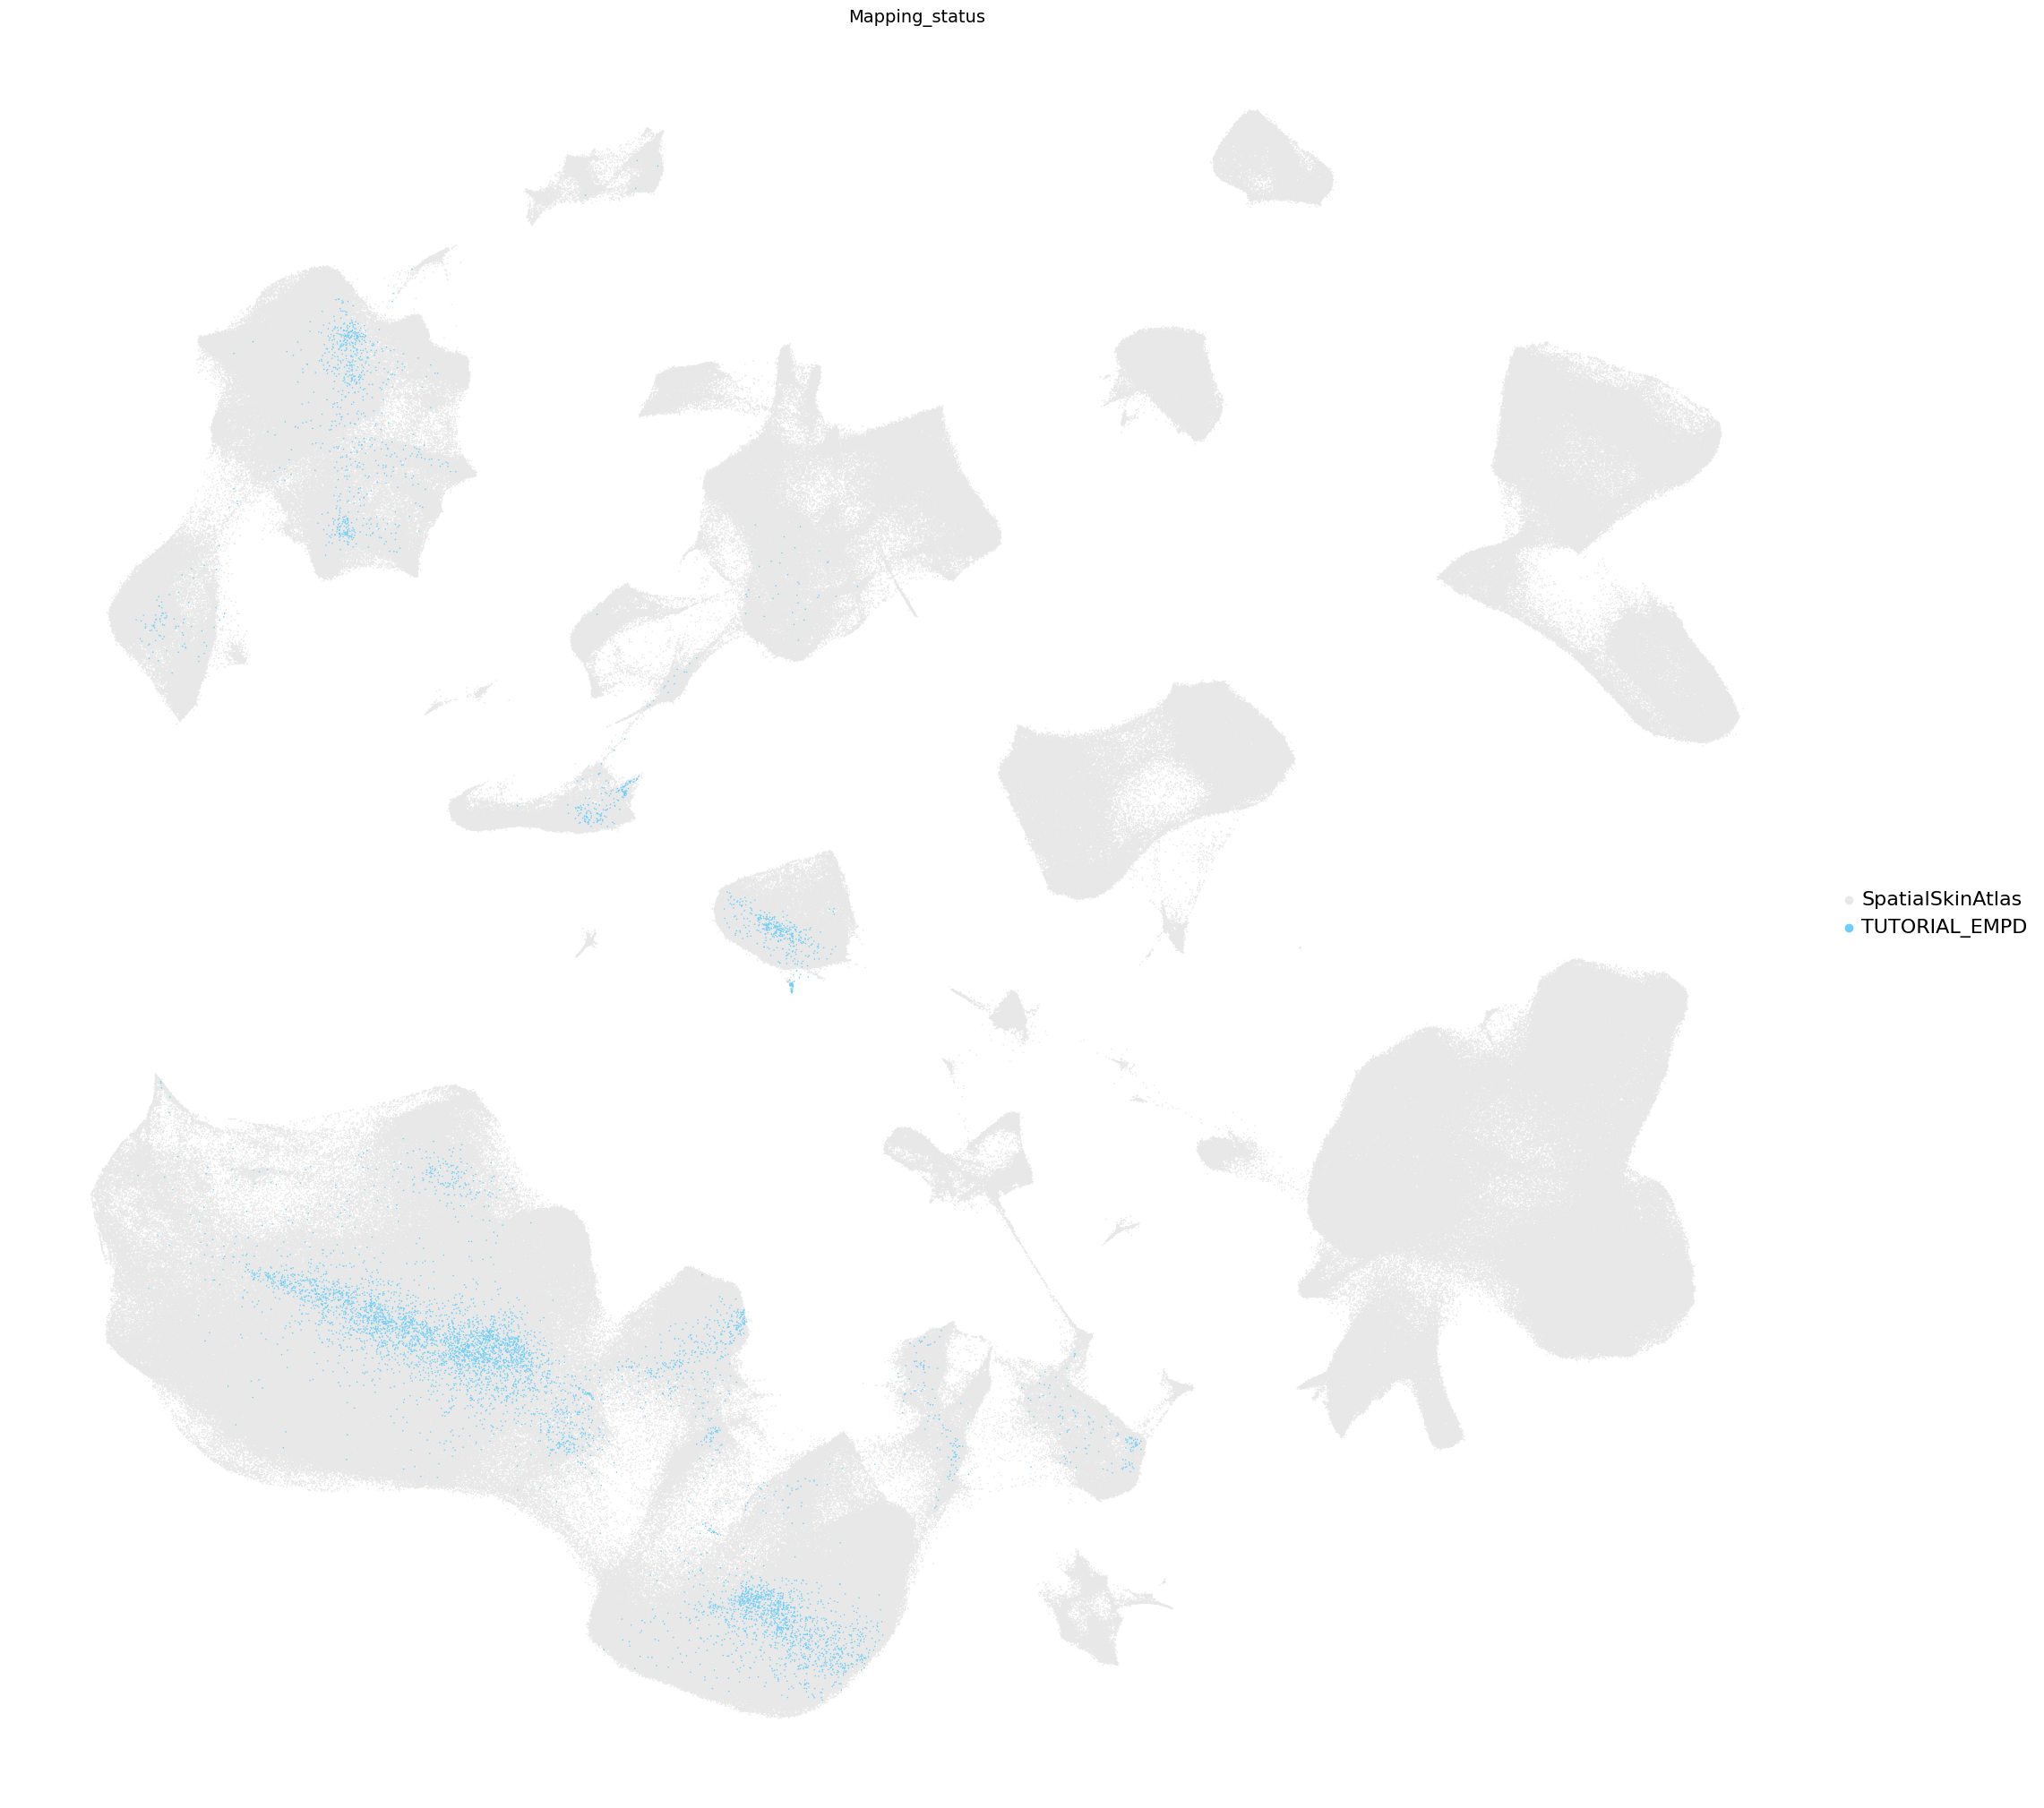

In [36]:
"""
Show how new data maps to atlas. Note that if no QC has been performed, a low QC cluster often forms (but in this dataset, QC had already been performed)

Looks like a good outcome! what a relief
"""

sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(26,26))

sc.pl.umap(
    adata,
    color=[
        'Mapping_status',  
    ],
    #legend_loc="on data",
    s=5, 
    legend_fontoutline=2,
    legend_fontsize=16,

       palette = {
    "SpatialSkinAtlas": "#E8E8E8",   
    DATASET: "#6ECFF6"            # swaecation sky blue
}         
)



In [37]:
!wget "https://raw.githubusercontent.com/haniffalab/spatial_skin_atlas/main/misc/color_for_adult_skin2.pkl" \
     -O color_for_adult_skin2.pkl

import pickle
file_path = "./color_for_adult_skin2.pkl"

with open(file_path, "rb") as f:
    colors = pickle.load(f)
colors= colors | {'New/unlabelled/excluded': "#C8C8C8"}
print(f"Loaded {len(colors)} colour entries")

/software/isg/languages/Python/Python-3.11.4/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


--2026-06-20 14:52:12--  https://raw.githubusercontent.com/haniffalab/spatial_skin_atlas/main/misc/color_for_adult_skin2.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4369 (4.3K) [application/octet-stream]
Saving to: ‘color_for_adult_skin2.pkl’

color_for_adult_ski 100%[===================>]   4.27K  --.-KB/s    in 0s      

2026-06-20 14:52:12 (52.7 MB/s) - ‘color_for_adult_skin2.pkl’ saved [4369/4369]

Loaded 195 colour entries


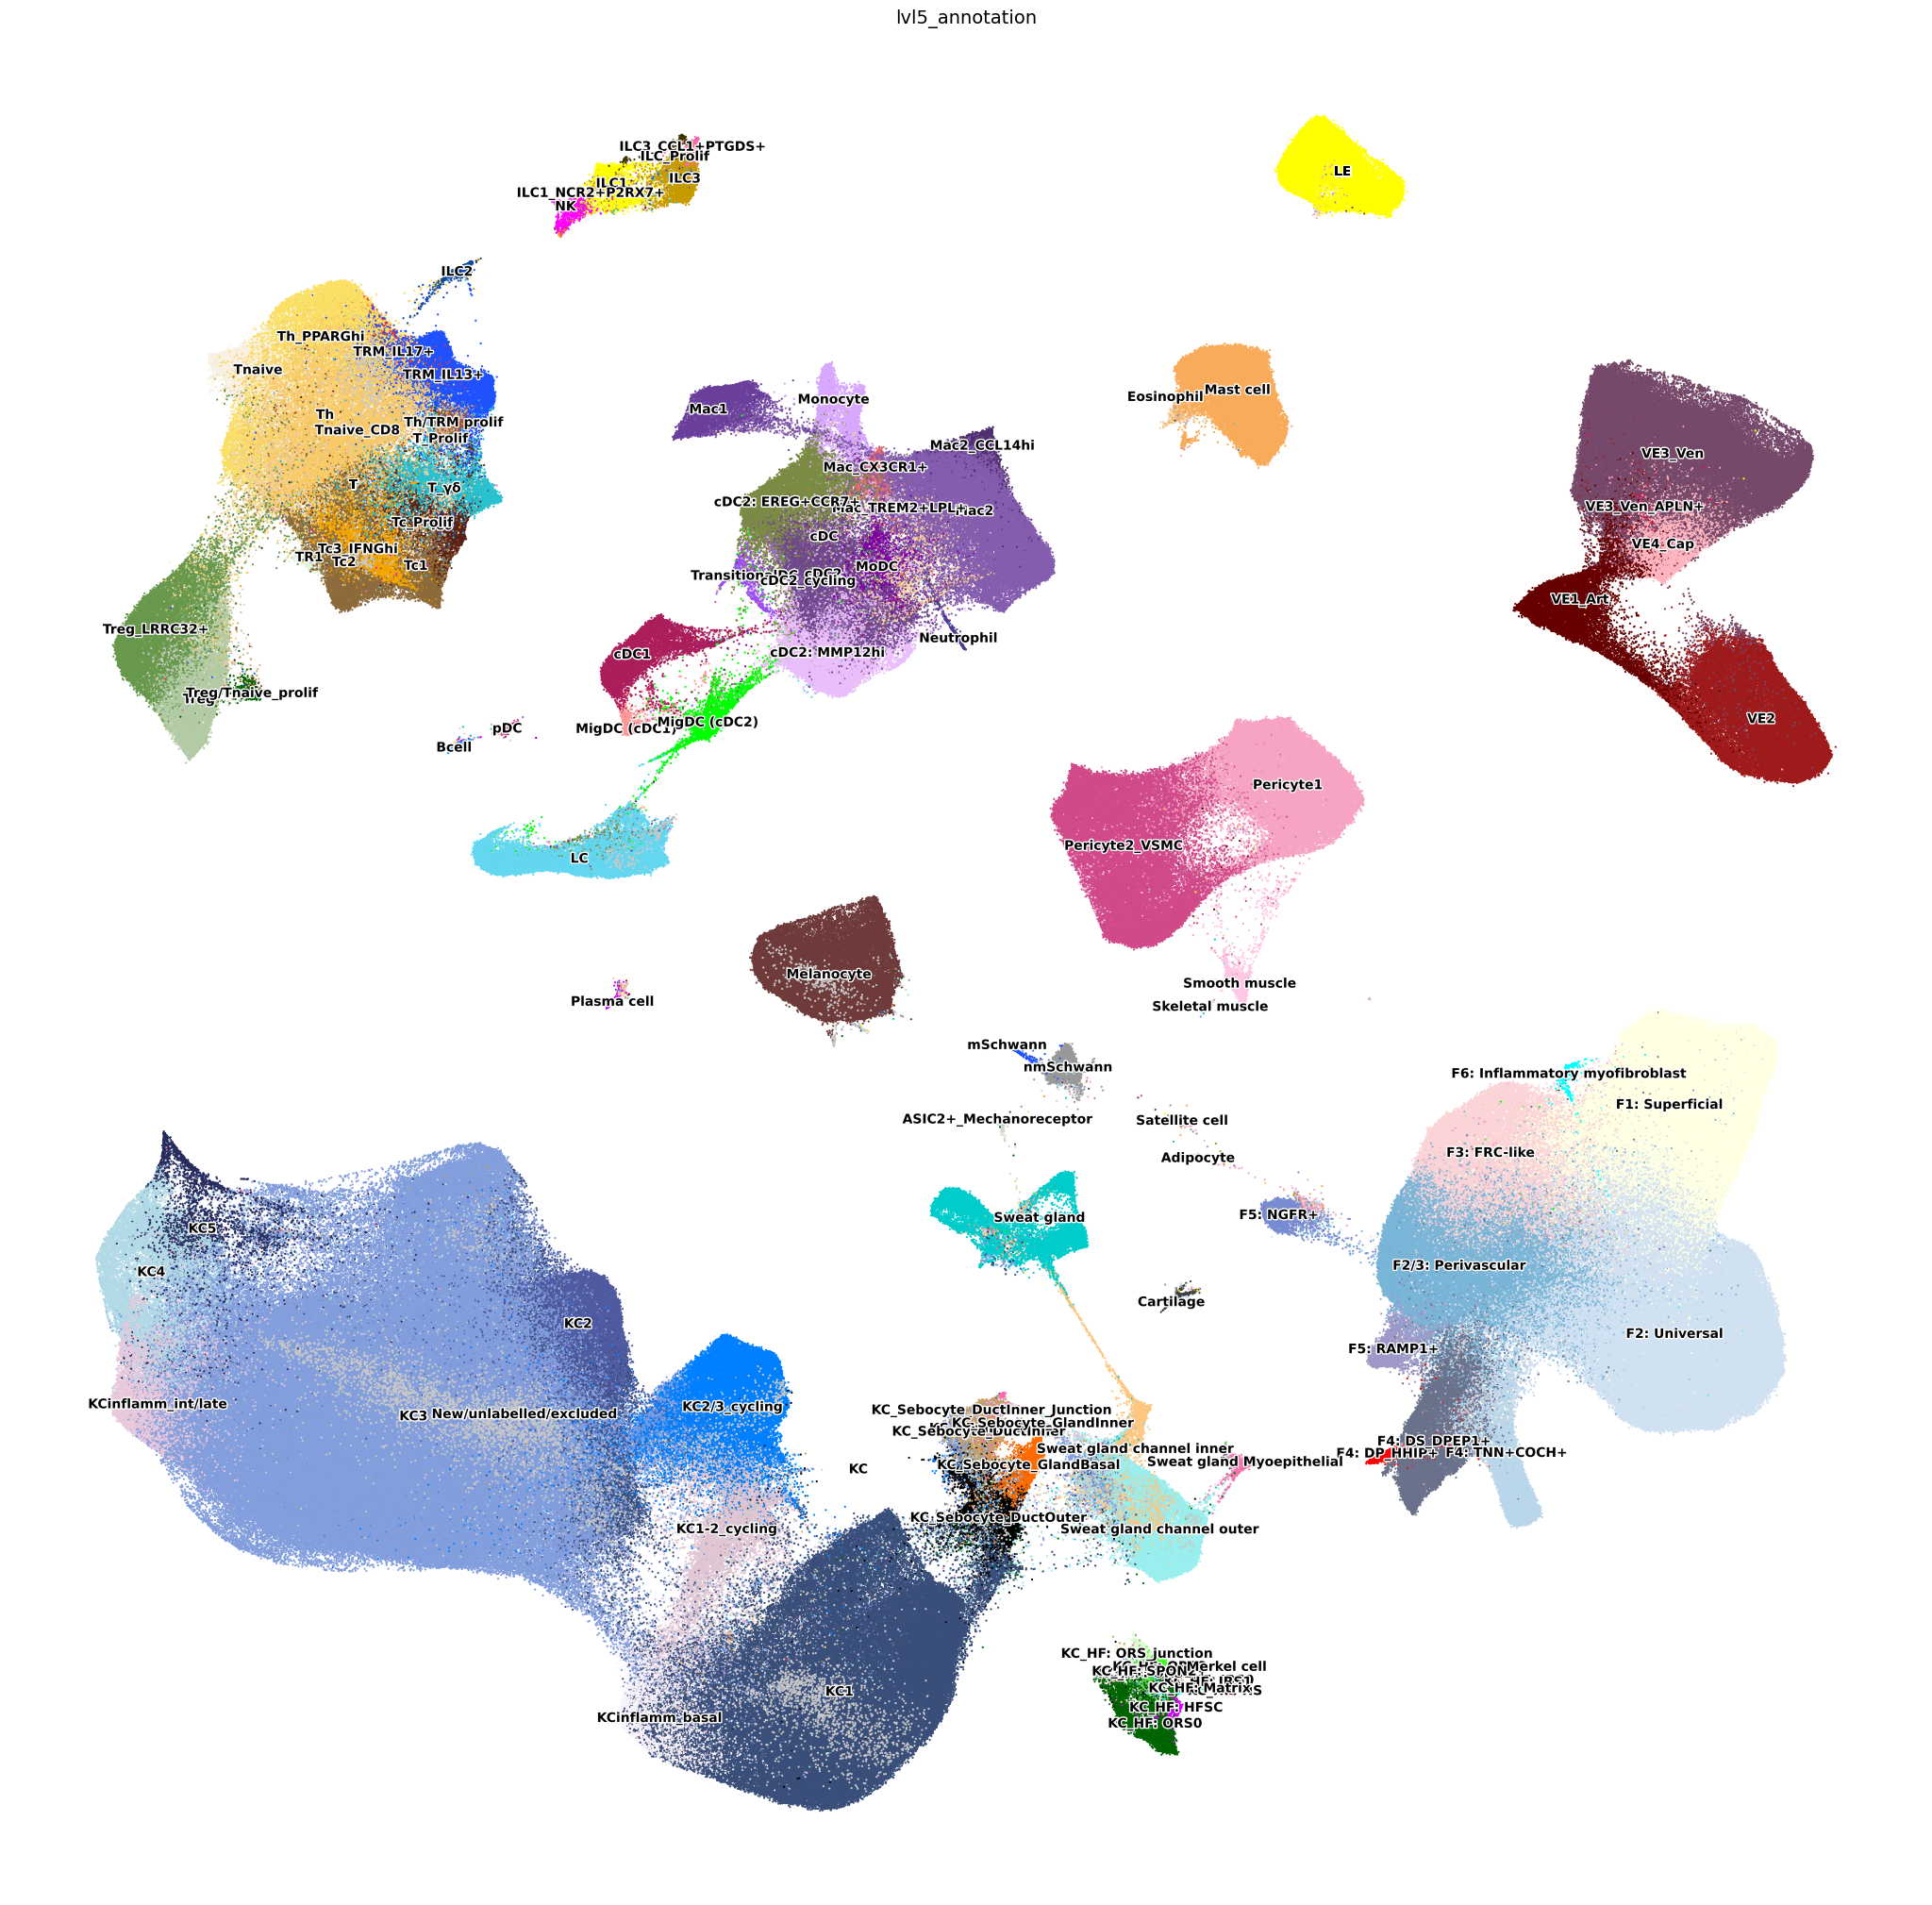

In [38]:
adata.obs["lvl5_annotation"] = (
    adata.obs["lvl5_annotation"]
    .astype("category")
    .cat.add_categories(["NA"])
    .fillna("NA")
)

colors["NA"] = "#6ECFF6"   # sky blue or whatever

sc.pl.umap(
    adata,
    color="lvl5_annotation",
    legend_loc="on data",
    s=10,
    legend_fontsize=10,
    legend_fontoutline=2,
    palette=colors
)

In [52]:
# sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(26,26))

# try:
#     print(f"Loaded {len(colors)} colour entries")
#     sc.pl.umap(
#         adata,
#         color=["lvl5_annotation"],
#         legend_loc="on data",
#         s=10,
#         legend_fontsize=10,
#         legend_fontoutline=2,
#         show=False,
#         palette=colors, 
#         #fillna_color= "#6ECFF6" 
#     )
# except:
#     try:
#         import glasbey
#         key = "lvl5_annotation"
#         cats = adata.obs[key].astype("category").cat.categories
#         palette = glasbey.create_palette(palette_size=len(cats), as_hex=True)
#         adata.uns[f"{key}_colors"] = palette

#         sc.pl.umap(
#         adata,
#         color=[key],
#         legend_loc="on data",
#         s=10,
#         legend_fontsize=10,
#         legend_fontoutline=2,
#         show=False,
#         palette=colors
#     ) 
#     except:
#         sc.pl.umap(
#         adata,
#         color=[key],
#         legend_loc="on data",
#         s=10,
#         legend_fontsize=10,
#         legend_fontoutline=2,
#         show=False,
#     ) 




In [ ]:
# adata_mappeddata.shape

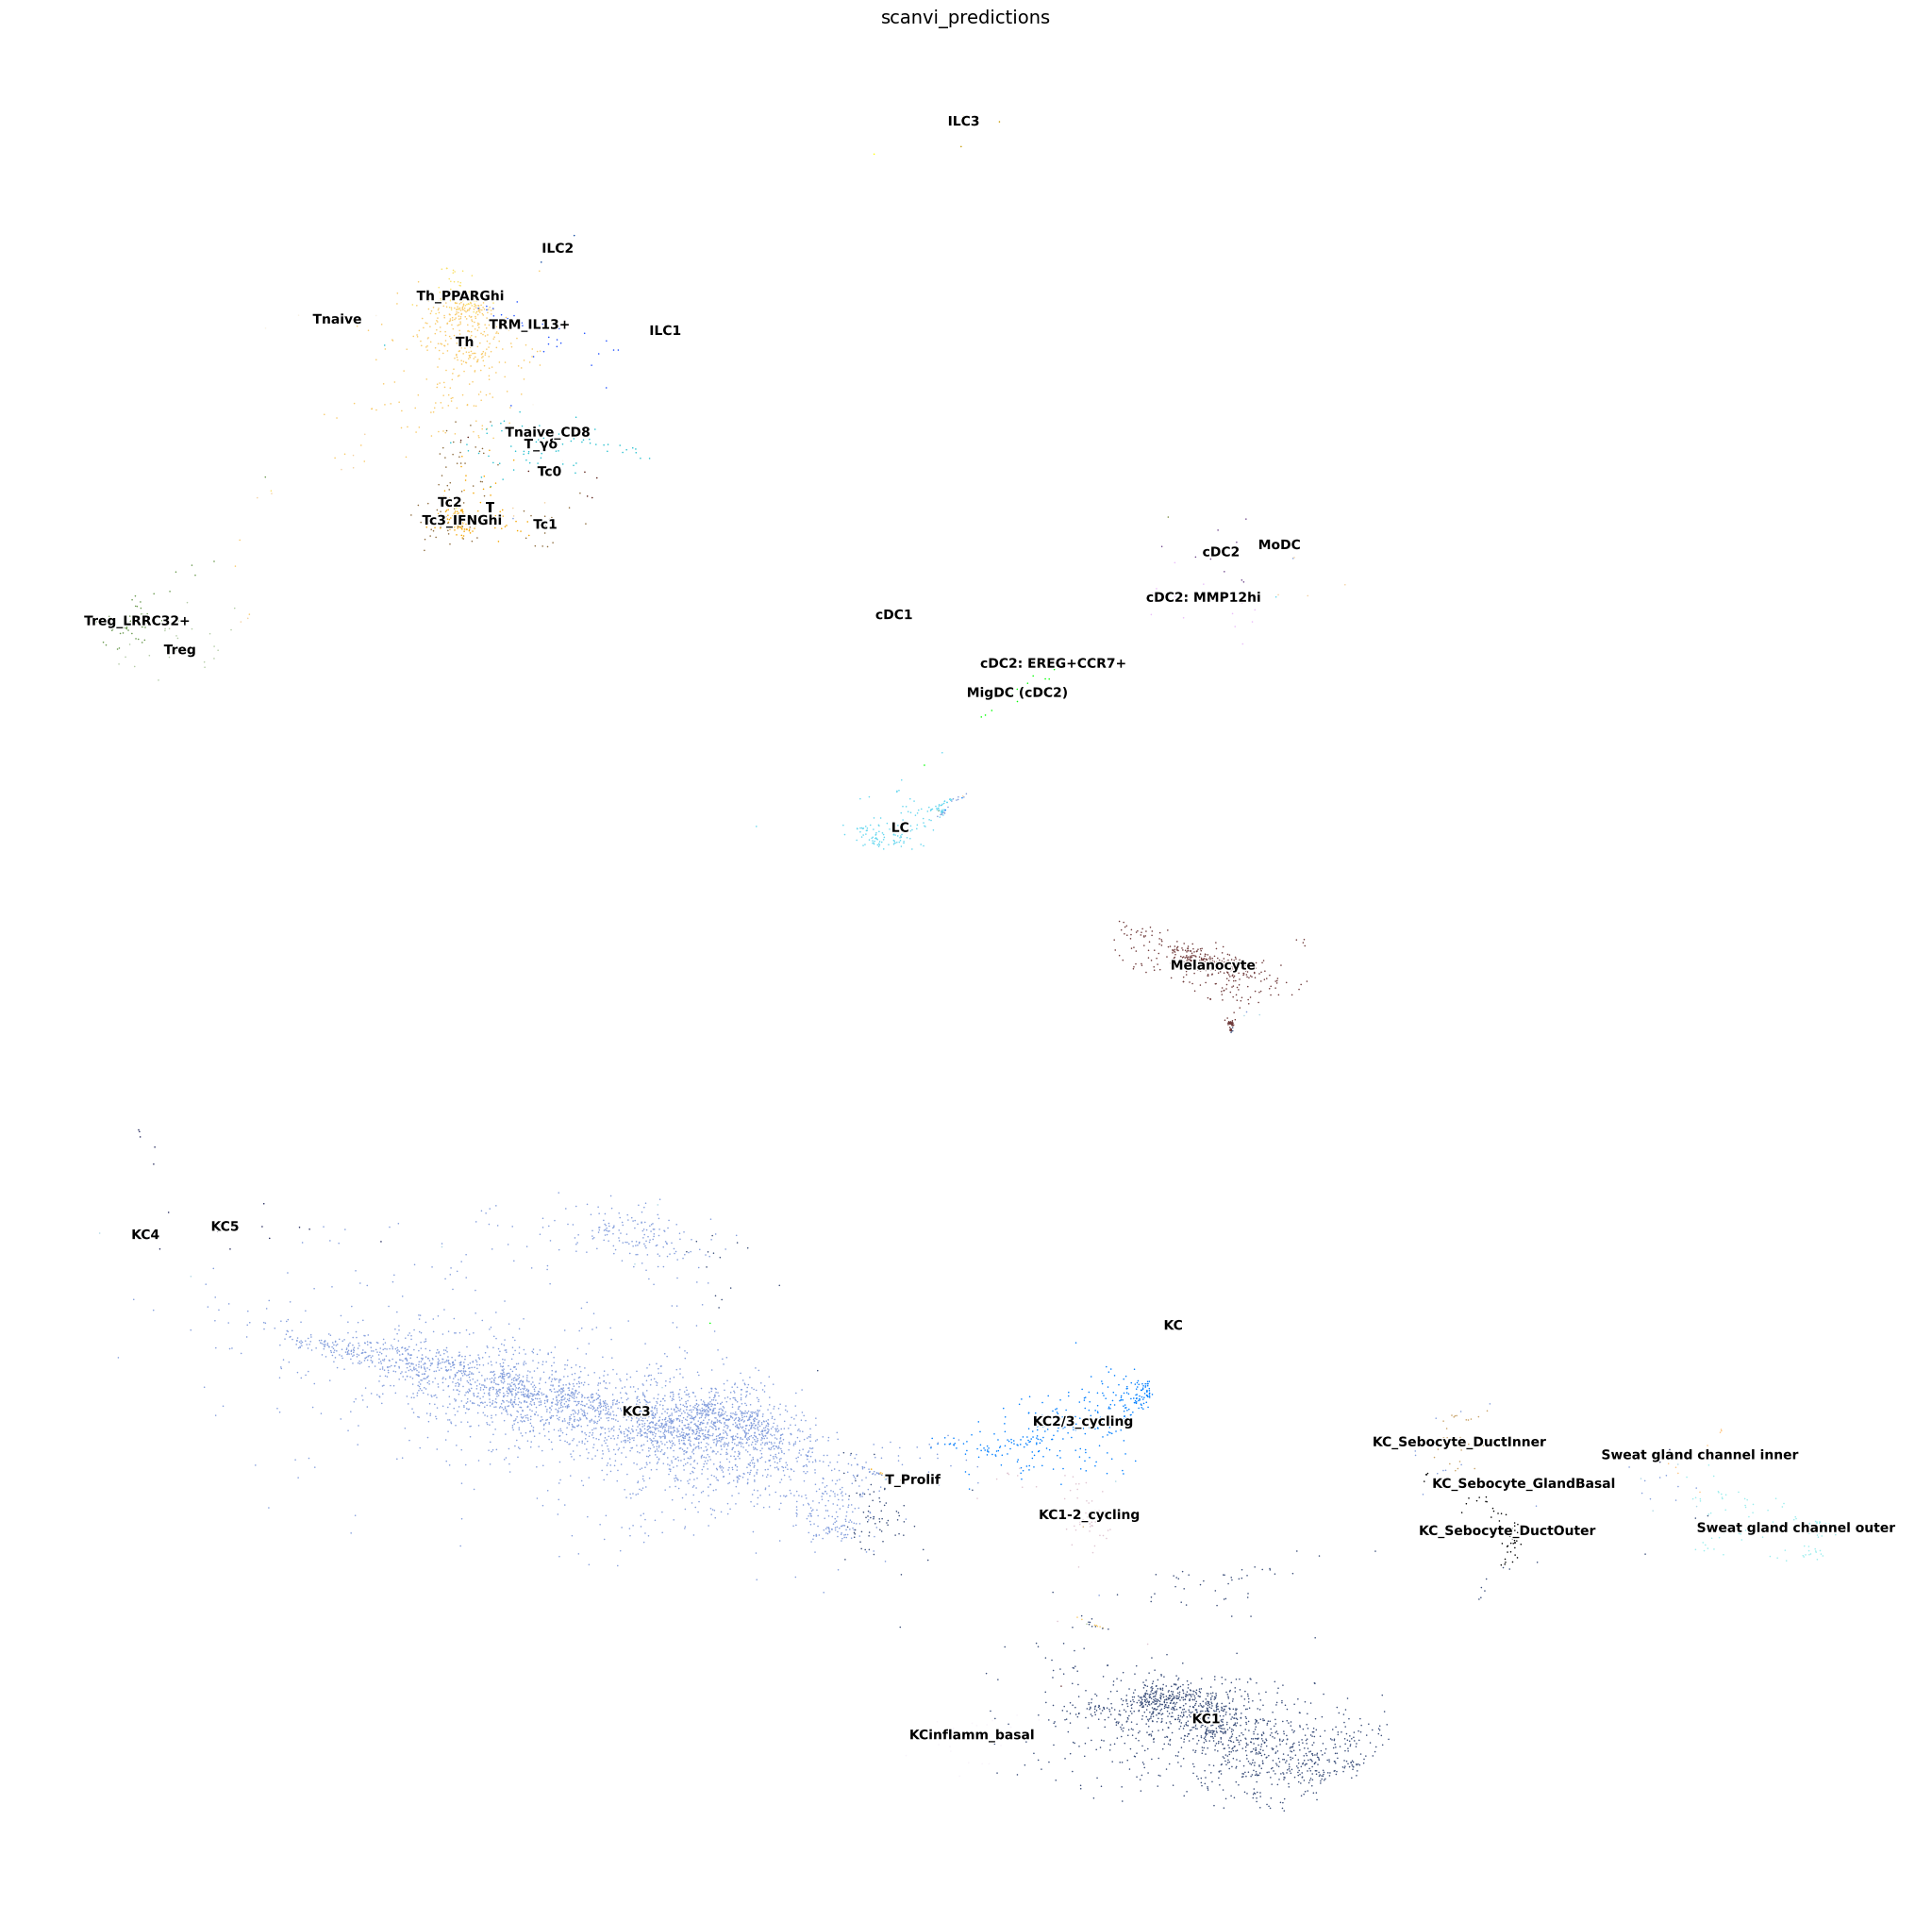

In [40]:
"""
We can also see what scanvi predictions are, but in my experience these have not been too reliable
compared to manually annotating the data.

However, not too bad for a quick overview.
"""
#sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(16,16))
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(26,26))

adata_mappeddata=adata[adata.obs["Mapping_status"]!="SpatialSkinAtlas"].copy()
sc.pl.umap(
    adata_mappeddata,
    color=[
        'scanvi_predictions',  
    ],
    legend_loc="on data",
    s=5, 
    legend_fontoutline=2,
    legend_fontsize=10,
    palette=colors,
)


# Let's check population expression

# fibroblasts

In [41]:
CATEGORY="scanvi_predictions"


In [51]:
adata_i = adata_mappeddata[adata_mappeddata.obs[CATEGORY].str.startswith("F")
               # (adata.obs["annotation"]=="Smooth muscle")|
                #(adata.obs["annotation"]=="Skeletal muscle")|
                #(adata.obs["annotation"]=="Satellite muscle")
               ]


desired_order =  [ 'F1: Superficial', #'F1: Regenerative', 
                  'F2: Universal',#'F2: Universal + fascia',
 #'F2/3: Stroma_PPARG+', 
                  'F2/3: Perivascular','F3: FRC-like',






 'F4: DS_DPEP1+',
 'F4: TNN+COCH+',
 'F4: DP_HHIP+',#'FP: DP_HHIP+', 
                  'F5: RAMP1+', 'F5: NGFR+', 'F6: Inflammatory myofibroblast',

 #'F_Fascia',
                 #'lowq', "missing"
                 ]

if not pd.api.types.is_categorical_dtype(adata_i.obs[CATEGORY]):
    adata_i.obs[CATEGORY] = adata_i.obs[CATEGORY].astype('category')

 
missing_data = 0
for x in list(adata_i.obs[CATEGORY].unique()):
    if x not in desired_order:
        print(x)
        missing_data +=1
if missing_data != 0:
    stop
        
        
# Set the categories in the desired order
adata_i.obs[CATEGORY] = pd.Categorical(
    adata_i.obs[CATEGORY],
    categories=desired_order,
    ordered=True
)
adata_i.obs[CATEGORY].unique() 

/tmp/ipykernel_2462884/1779651130.py:27: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata_i.obs[CATEGORY]):
/tmp/ipykernel_2462884/1779651130.py:41: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[CATEGORY] = pd.Categorical(


[], Categories (10, object): ['F1: Superficial' < 'F2: Universal' < 'F2/3: Perivascular' < 'F3: FRC-like' ... 'F4: DP_HHIP+' < 'F5: RAMP1+' < 'F5: NGFR+' < 'F6: Inflammatory myofibroblast']

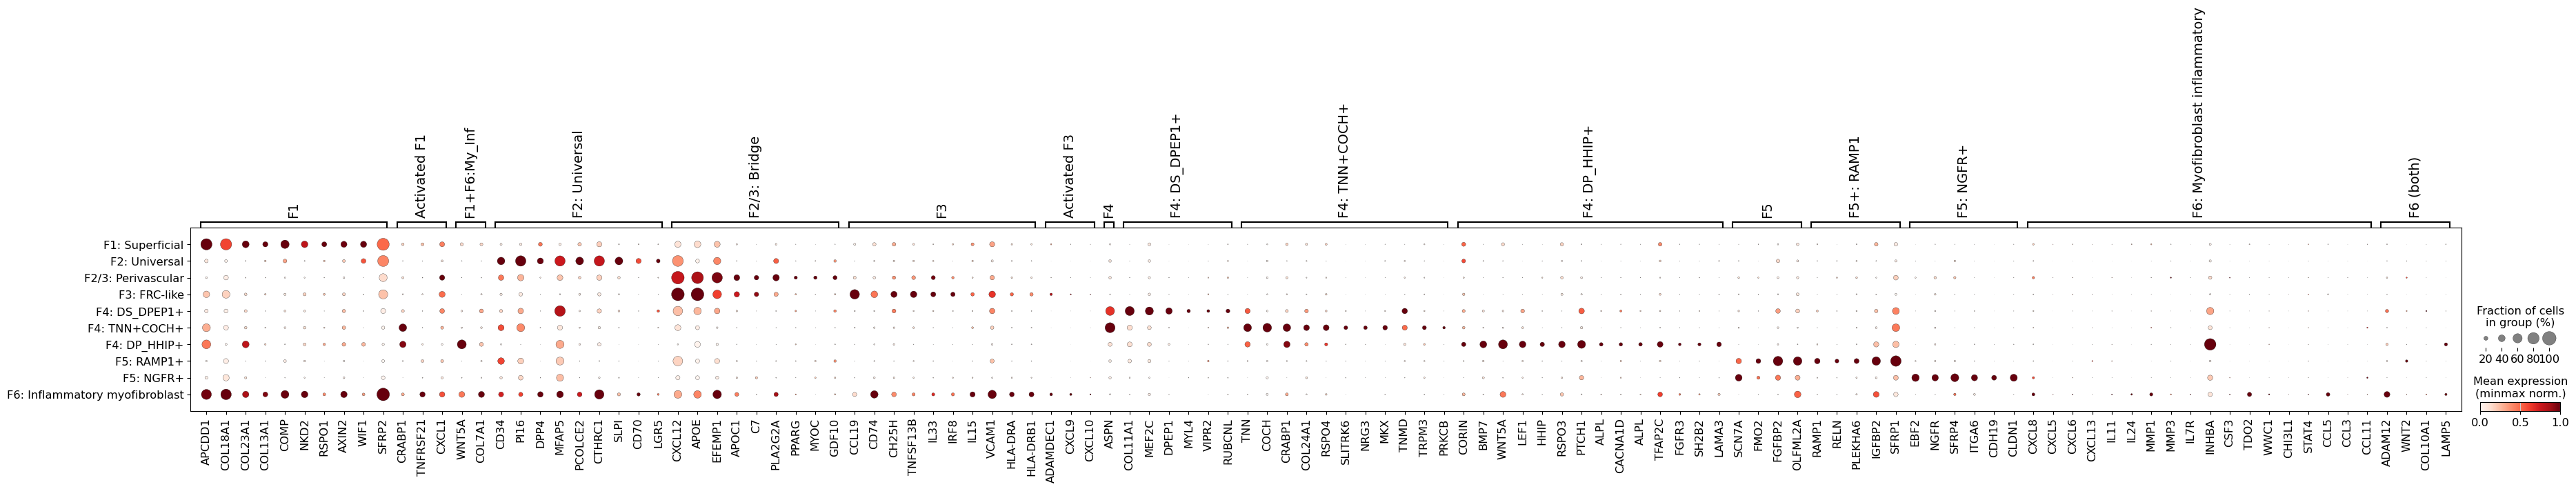

In [45]:
def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata.var_names]
    return LIST


FBS = {'F1': ['APCDD1',
  'COL18A1',
  'COL23A1',
  'COL13A1',
  'COMP',
  'NKD2',
  'RSPO1',
  'AXIN2',
  'WIF1',
  'SFRP2'],
                    "Activated F1": [ 'CRABP1',
  'TNFRSF21',
  'CXCL1'],
                   'F1+F6:My_Inf': ['WNT5A', 'COL7A1'],
 'F2: Universal': ['CD34',
  'PI16',
  'DPP4',
  'MFAP5',
  'PCOLCE2',
  'CTHRC1',
  'SLPI',
  'CD70',
  'LGR5'],
 'F2/3: Bridge': ['CXCL12',
  'APOE',
  'EFEMP1',
  'APOC1',
  'C7',
  'PLA2G2A',
  'PPARG',
  'MYOC',
  'GDF10'],
 'F3': ['CCL19',
  'CD74',
  'CH25H',
  'TNFSF13B',
  'IL33',
  'IRF8',
  'IL15',
  'VCAM1',
  'HLA-DRA',
  'HLA-DRB1'],
          "Activated F3": ["ADAMDEC1", "CXCL9", "CXCL10"],
 'F4': ['ASPN'],
 'F4: DS_DPEP1+': ['COL11A1', 'MEF2C', 'DPEP1', 'MYL4',  "VIPR2", "RUBCNL"],
 'F4: TNN+COCH+': ['TNN',
  'COCH',
  'CRABP1',
  'COL24A1',
  'RSPO4',
  'SLITRK6',
  'NRG3',
  'MKX',
  'TNMD',  "TRPM3", "PRKCB",],
 'F4: DP_HHIP+': ['CORIN',
  'BMP7',
  'WNT5A',
  'LEF1',
  'HHIP',
  'RSPO3',
  #'INHBA',
  'PTCH1', "ALPL", "CACNA1D", "ALPL", "TFAP2C","FGFR3", "SH2B2","LAMA3",
],
 'F5': ['SCN7A', 'FMO2', 'FGFBP2', 'OLFML2A'],
 'F5+: RAMP1': ['RAMP1', 'RELN', 'PLEKHA6', 'IGFBP2', 'SFRP1'],
 'F5: NGFR+': ['EBF2', 'NGFR', 'SFRP4', 'ITGA6', 'CDH19', 'CLDN1'],
'F6: Myofibroblast inflammatory': ['CXCL8',
  'CXCL5',
  'CXCL6',
  'CXCL13',
  'IL11',
  'IL24',
  'MMP1',
  'MMP3',
  'IL7R',
  'INHBA',
  'CSF3',
  'TDO2',
  'WWC1',
  'CHI3L1',
  'STAT4',
  'CCL5',
  'CCL3',
  'CCL11'],
 'F6 (both)': ["ADAM12",'WNT2', 'COL10A1', 'LAMP5'],
         
         }


sc.pl.dotplot(
    adata_i,
       remove_markers(FBS),
    groupby=CATEGORY,
    #vmax=1.1,
   standard_scale="var",
    dendrogram=False,
                           colorbar_title="Mean expression\n(minmax norm.)",
)

 

# t cells (recommend further manual annotation)

In [53]:
adata_i = adata_mappeddata[#(adata.obs["lvl1_new"].str.startswith("T"))
              (adata_mappeddata.obs[CATEGORY].str.startswith("T"))|
    (adata_mappeddata.obs[CATEGORY].str.startswith("ILC"))|
    (adata_mappeddata.obs[CATEGORY].str.startswith("NK"))
               ]
adata_i = adata_i[~(adata_i.obs[CATEGORY].str.startswith("Tran"))]
adata_i.obs[CATEGORY].value_counts()

scanvi_predictions
Th              398
Tc3_IFNGhi      119
T_γδ             75
Tc2              63
Treg_LRRC32+     55
Th_PPARGhi       55
TRM_IL13+        35
Treg             27
T                19
Tc1              16
Tc0               9
Tnaive            4
T_Prolif          3
ILC3              3
ILC2              2
Tnaive_CD8        2
ILC1              2
Name: count, dtype: int64

In [54]:
desired_order = [ 'Treg',"Treg_LRRC32",'Treg_LRRC32+',
                  'Tr1','TR1','T_lowq maybe',
                'Tnaive','Tnaive_CD8',
                  'Tnaive/Tcm','Tnaive/Tcm,1','Tnaive/Tcm,0','Tnaive (blood)','TRM/Tnaive',
    
                 'T_CD4_naive','Th_MCAMhi_PTGS2+', 
                  'Th','Th_MCAMhi',
                 'Th_CXCR6+',
                 'Th_PPARGhi',
                 'Tc0',
                 'Tc0_IL9R+_GPR15hi',"Tc_IL9R+GPR15hi",'Tc_GPR15hi',
               'Tc_naive','Tc1',
                  'Tc','Tc2','Tc_IFNGhi1',
                  'Tc_IFNGhi','Tc1_IFNGhi', 'Tc_IFNGhi2', 'Tc2_IFNGhi',
                 'Tc3_IFNGhi',
                 
                 
                 'TRM_IL13+',
'TRM_IL17+_Cytotoxic',                 'TRM_IL17+_other',


                  'Tc_IL13','TRM_IL22_2','TRM_IL22','T*RM*_IL22','TRM_IL13',
                  'Tc_IL17','TRM_IL17+mixed','TRM_IL17+','TRM_IL17','TRM_IL17lo','T_ITGA1hi',
'TRM',
 'Tc_gamma_delta','Tc_ZNF683+/γδ', "T_γδ",  'TRM_ZNF683+', 'Tc_ZNF683+','TRM_ZNF683+ITGA1+',
  'T',
 'NK',

 'ILC1_NK','ILC1_NK_cycling',
                 'ILC1','ILC1_NCR2+P2RX7+',



'ILC3',
    'ILC1_3','ILC1_3_cycling',    'ILC1_3_CCL1hi_cycling','ILC3_CCL1+PTGDS+',  'ILC_Prolif',
 
'ILC2',



'T_Prolif',


'Eosinophils', 
'Eosinophil',"missing",
                 "Treg/Tnaive_prolif",
                 'Th/TRM prolif','TRM_Prolif',
'Treg_prolif',

'Tc_Prolif',
               
                 










                 


 ]


ORDER_T=desired_order


# Ensure 'lvl3_annotation' is categorical
if not pd.api.types.is_categorical_dtype(adata_i.obs[CATEGORY]):
    adata_i.obs[CATEGORY] = adata_i.obs[CATEGORY].astype('category')

missing_data = 0
for x in list(adata_i.obs[CATEGORY].unique()):
    if x not in desired_order:
        print(x)
        missing_data +=1
if missing_data != 0:
    stop
        

# Set the categories in the desired order
adata_i.obs[CATEGORY] = pd.Categorical(
    adata_i.obs[CATEGORY],
    categories=desired_order,
    ordered=True
)


/tmp/ipykernel_2462884/1141661065.py:73: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata_i.obs[CATEGORY]):
/tmp/ipykernel_2462884/1141661065.py:86: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[CATEGORY] = pd.Categorical(


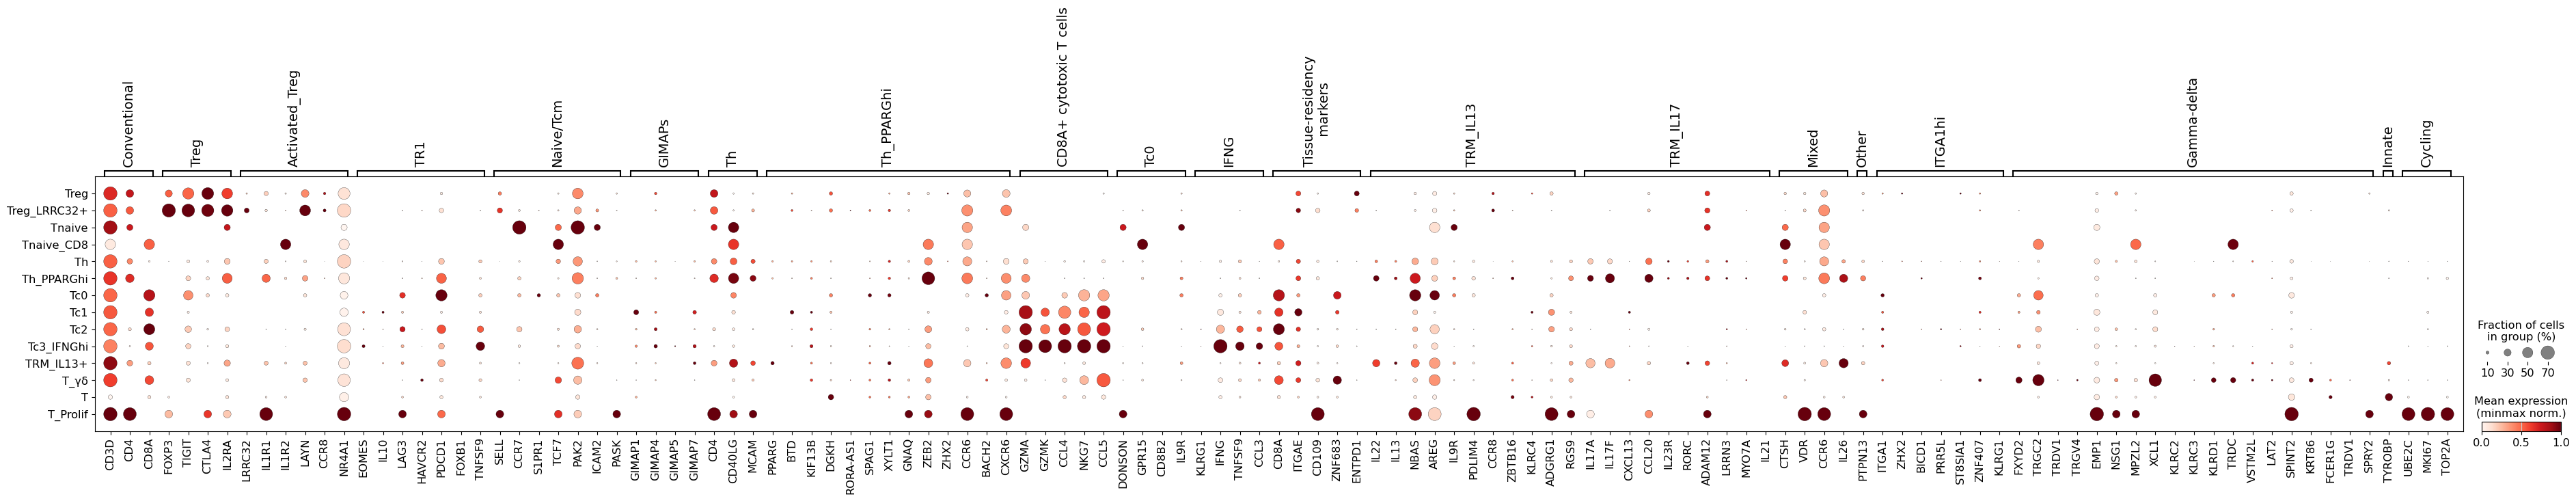

In [55]:
ALL_T = {'Conventional': ['CD3D', "CD4", "CD8A"],
 'Treg': ['FOXP3', 'TIGIT', 'CTLA4', 'IL2RA'],
 'Activated_Treg': ['LRRC32',
  'IL1R1',
  'IL1R2',
 # 'CMSS1',
  'LAYN',
  'CCR8',
  'NR4A1'],
 'TR1': ['EOMES',
  'IL10',
  'LAG3',
  'HAVCR2',
  'PDCD1',
  'FOXB1',
  'TNFSF9',
 # 'VCAM1'
        ],
  
 'Naive/Tcm': ['SELL', 'CCR7', 'S1PR1', 'TCF7', 'PAK2', 'ICAM2', 'PASK', ],
 'GIMAPs': ['GIMAP1', 'GIMAP4', 'GIMAP5', 'GIMAP7'],
 'Th': ['CD4', 'CD40LG', 'MCAM', ],
 'Th_PPARGhi': ['PPARG', 'BTD', 'KIF13B', 'DGKH', 'RORA-AS1','SPAG1',
         'XYLT1', 'GNAQ',  'ZEB2', # 'PTGS2', 'MMP7',
        "ZHX2",'CCR6', 'BACH2', "CXCR6",
               ],
         #"CD8": ["CD8A"],
        
                
 'CD8A+ cytotoxic T cells': [ 'GZMA', 'GZMK', 'CCL4','NKG7', 'CCL5',  ],
           'Tc0': ['DONSON', 'GPR15', 'CD8B2', 'IL9R', 
                     #"AGAP1", "C12orf42", "GML", "CCR5",
                     ],

         'IFNG': ["KLRG1",'IFNG', 'TNFSF9', 'CCL3'],
 'Tissue-residency\n markers': ['CD8A', 'ITGAE', 'CD109', 'ZNF683', 'ENTPD1'],
 'TRM_IL13': ['IL22', 'IL13', 'NBAS',# 'CCL17',
         'AREG', 'IL9R', 'PDLIM4', 'CCR8',
         'ZBTB16', 'KLRC4', 'ADGRG1', 'RGS9'],
 'TRM_IL17': ['IL17A',
  'IL17F',
  'CXCL13',
  'CCL20',
  'IL23R',
  'RORC',
  'ADAM12',  'LRRN3',
  'MYO7A',
  'IL21',],
    'Mixed': [

  'CTSH',
  'VDR',
  'CCR6',
  'IL26'
         ],
 'Other': ['PTPN13', #'ITGA1'
          ],
 'ITGA1hi': ['ITGA1', 'ZHX2', 'BICD1', 'PRR5L', 'ST8SIA1', 'ZNF407', "KLRG1"],
 #'Memory': ['CD69'],
 'Gamma-delta': ['FXYD2',
  'TRGC2',
  'TRDV1',
  'TRGV4',
  'EMP1',
  'NSG1',
  'MPZL2',
  'XCL1',
  'KLRC2',
  'KLRC3',
  'KLRD1',
  'TRDC',
  'VSTM2L',
  'LAT2',
  'SPINT2',
  'KRT86',
  'FCER1G',
  'TRDV1',
  'SPRY2'],
 'Innate': [#'KLRC2', 'KLRC3', 'KLRB1', 'KIT', 'KLRC1',
     'TYROBP',],
 #'ILC2': ['GATA3', 'PTGDR2', 'TNFRSF25'],
                 'Cycling': ['UBE2C', 'MKI67', 'TOP2A'],
        # "tfh": ['IL21', "CXCL13", "ICOS", 'CXCR5', 'PDCD1', 'BCL6', 
           

 # 'ILC2_inflammatory': ['CRLF2',
 #  'IL17RB',
 #  'IL1RL1',
 #  'IL18R1',
 #  'PLA2G4A',
 #  'IL4',
 #  'IL31',
 #  'ICOS',
 #  'NRROS'],

        }
 
adata_ii = adata_i[~(adata_i.obs[CATEGORY].str.startswith("ILC"))]
adata_ii = adata_ii[~(adata_ii.obs[CATEGORY].str.startswith("NK"))]

sc.pl.dotplot(adata_ii, 
              ALL_T,
              groupby=CATEGORY,
              dendrogram=False, 
                standard_scale="var",
              dot_max=.7,
             categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()],
             # save="T_scrna.pdf",
                           colorbar_title="Mean expression\n(minmax norm.)"

             )

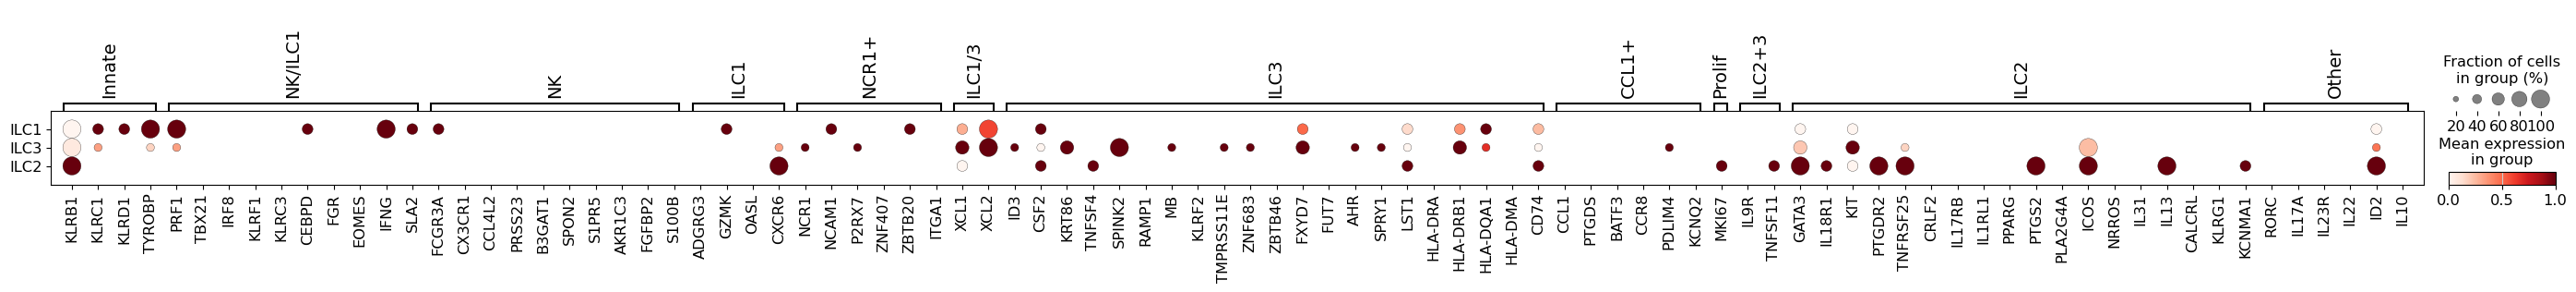

In [60]:
ALLT2 = {'Innate': [
  'KLRB1',
  'KLRC1',"KLRD1",
  'TYROBP',
  #'FCER1G',
],
         "NK/ILC1": ['PRF1',#'KLRD1',
                     'TBX21','IRF8',  'KLRF1',
  #'KLRG1',#'KLRC2',
  'KLRC3', 'CEBPD',"FGR", "EOMES", "IFNG", 'SLA2', #'KIR2DL4', 'SH2D1B', 'SLFN13', 'TMIGD2'
                    ],
 'NK': [  'FCGR3A',
 
  'CX3CR1',
  'CCL4L2',
  'PRSS23', 'B3GAT1',
       'SPON2',
  'S1PR5',
  'AKR1C3',
         'FGFBP2',



  'S100B'],

         "ILC1": [ "ADGRG3", 'GZMK', 'OASL', 'CXCR6' ,# "TNFSF10" 
                 ],
         "NCR1+":  [ 'NCR1', 'NCAM1',  'P2RX7',   'ZNF407', #"IL18",
                         'ZBTB20',# 'CASK',# "ITGA1",
                     #  'PLCB1', 'ADAM28',  'CNR2', "KLRG1",
                         "ITGA1"
                        ],
         
 'ILC1/3': ['XCL1', 'XCL2', ],
          'ILC3': ['ID3','CSF2', 'KRT86',
 # 'ZBTB46',
  'TNFSF4',
  'SPINK2',
  'RAMP1',
  'MB',
  'KLRF2',
  'TMPRSS11E', "ZNF683", "ZBTB46",
                  "FXYD7", "FUT7", "AHR", "SPRY1", "LST1",
                                    'HLA-DRA',  "HLA-DRB1",'HLA-DQA1',  "HLA-DMA",'CD74' 

                  ],
           'CCL1+': [  'CCL1',  'PTGDS',"BATF3",
                   # "MYO1E", "PTGER3",
                     #'CDCP1', 'LILRA2','HHEX', 
                     'CCR8', 'PDLIM4','KCNQ2', 
                    ],
    "Prolif": ["MKI67"],

 'ILC2+3': ['IL9R', 'TNFSF11'],
 'ILC2': ['GATA3',  'IL18R1','KIT', 'PTGDR2', 'TNFRSF25',
          'CRLF2',
  'IL17RB',
  'IL1RL1',

  'PPARG',
  'PTGS2',
  'PLA2G4A',
  #'IL4',

  'ICOS',
  'NRROS',     'IL31',
#'IL22',
          'IL13', #"IL5",#'PDLIM4', 'CCL1',
          #'AREG', 'CCR8',
          'CALCRL',"KLRG1",
         
         
         # "MAF", "MCAM", "NTRK2", "IL26","PLN",
          "KCNMA1",
         ],
         "Other": ["RORC", "IL17A", "IL23R", "IL22", "ID2", "IL10",],
  # 'Naive/Tcm': ['SELL', 'CCR7', 'S1PR1', 'TCF7', 'PAK2', 'ZHX2'],
 #        "NEW": ["PLXDC2", "AIF1", "RAB34", "NEDD4L", "PM20D2", "TNRC18", "JCHAIN", ],
 # 'Cycling': ['UBE2C', 'MKI67', 'TOP2A'],
 #        "RORC+": ["RORC",]
        }

             
sc.pl.dotplot(adata_i[(adata_i.obs[CATEGORY].str.startswith("ILC"))|
                      (adata_i.obs[CATEGORY].str.startswith("NK"))
                     ]        , 
              ALLT2,
              groupby=CATEGORY,
              dendrogram=False, 
                standard_scale="var",
 

            # categories_order = [x for x in ORDER_T if x in adata_ii.obs[CATEGORY].unique()]

             )

In [58]:
"""
NOTE, sometimes ILC polarisations aren't correct (e.g. ILC1_NCR+ vs ILC1),
so consider grouping
"""

"\nNOTE, sometimes ILC polarisations aren't correct (e.g. ILC1_NCR+ vs ILC1),\nso consider grouping\n"

# Other

In [62]:
adata_i = adata_mappeddata[(adata_mappeddata.obs[CATEGORY].str.startswith("ASIC"))|
                (adata_mappeddata.obs[CATEGORY].str.startswith("Me"))|
                 (adata_mappeddata.obs[CATEGORY].str.startswith("Satel"))|
                (adata_mappeddata.obs[CATEGORY].str.startswith("Adip"))|
               (adata_mappeddata.obs[CATEGORY]=="Bcell")|
                   (adata_mappeddata.obs[CATEGORY]=="Plasma cell")|
                                               (adata_mappeddata.obs[CATEGORY]=="Cartilage")|

                               (adata_mappeddata.obs[CATEGORY]=="mSchwann")|
                     (adata_mappeddata.obs[CATEGORY]=="nmSchwann")
                
               ]
adata_i=adata_i[adata_i.obs[CATEGORY]!="Mast cell"]
adata_i.shape

(422, 32732)

In [63]:
import pandas as pd
desired_order = [ 'Melanocyte', 'mSchwann',  'nmSchwann', 
                 'Merkel cell',"Mechanoreceptor_ASIC2+", "Mechanoreceptor ASIC2+","ASIC2+_Mechanoreceptor",

                 'Cartilage',  'Adipocyte', #'Mast cell',
               'Bcell', "Plasma cell2", 'Plasma cell', 
                # 'Neutrophil'
                 'Melanocyte doublet3',
'nmSchwann*',
'Erythroid',
'Merkel partly?',
'Melanocyte_T doublet2',
'Melanocyte doublet1',
'Satellite muscle', 'Satellite cell', "missing"
                ]


# Ensure 'lvl3_annotation' is categorical
if not pd.api.types.is_categorical_dtype(adata_i.obs[CATEGORY]):
    adata_i.obs[CATEGORY] = adata_i.obs[CATEGORY].astype('category')

if not pd.api.types.is_categorical_dtype(adata_i.obs[CATEGORY]):
    adata_i.obs[CATEGORY] = adata_i.obs[CATEGORY].astype('category')

missing_data = 0
for x in list(adata_i.obs[CATEGORY].unique()):
    if x not in desired_order:
        print(x)
        missing_data +=1
if missing_data != 0:
    stop
        

# Set the categories in the desired order
adata_i.obs[CATEGORY] = pd.Categorical(
    adata_i.obs[CATEGORY],
    categories=desired_order,
    ordered=True
)



/tmp/ipykernel_2462884/3822947581.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata_i.obs[CATEGORY]):
/tmp/ipykernel_2462884/3822947581.py:22: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata_i.obs[CATEGORY]):
/tmp/ipykernel_2462884/3822947581.py:35: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[CATEGORY] = pd.Categorical(


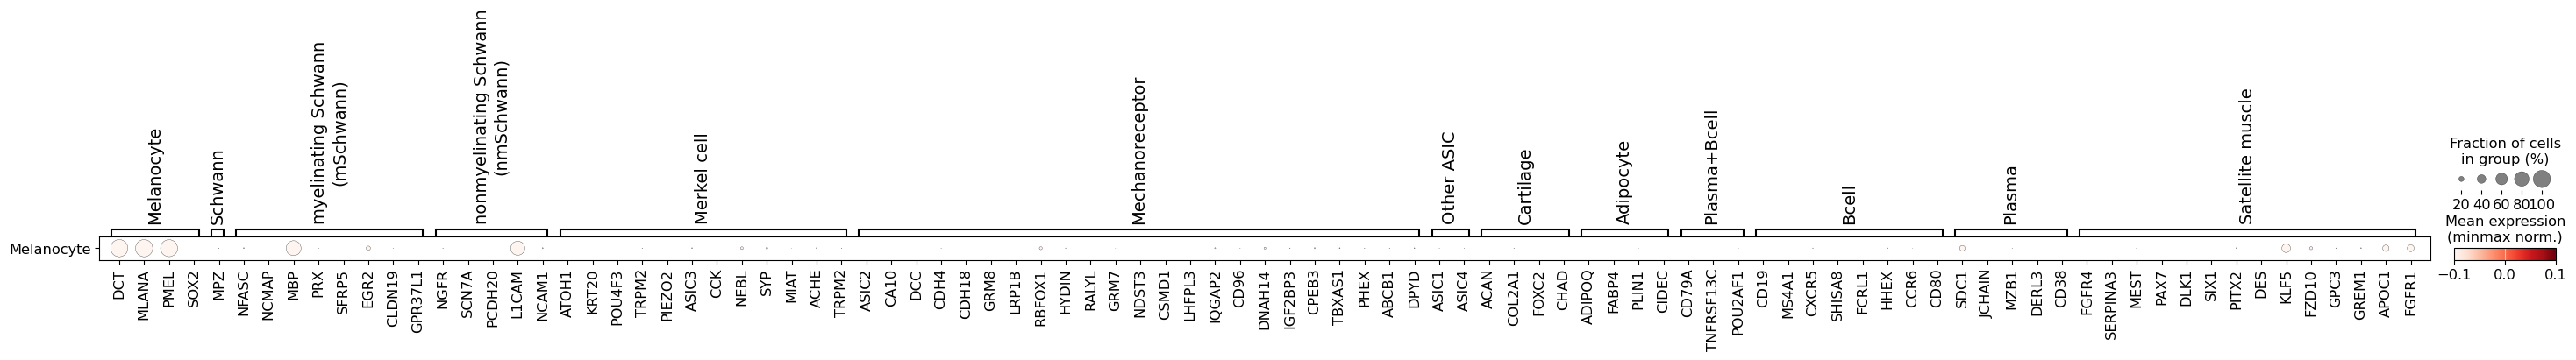

In [65]:
MISC_IMMUNE_SHORT = {#"LRRC32_genes": ["SIRT6", "GRWD1", "CWC25", "LRRC32", "ARMCX1", "MRPL50", "PID1", "ZNF593", "NR1D1",
               #                "CCRL2" , "FOSL1", "ACHE", "SYNGAP1", "PHLDB1" , "IRF2"],
               #"TREM2_MAC": ["AXL", "C3", "FCGR3A", "TNFSF13", "IGSF21", "TREM2", "CD276", "SOCS6", "MERTK", "TNFSF12", "SLC12A5", "HTRA1", "IFITM10"],
               
        #"BCELL+PLASMA+PDC": ["IGKC",  "MZB1","ST6GALNAC4", "GAB1",],
        "Melanocyte": ["DCT", "MLANA", "PMEL", "SOX2",],
    "Schwann": ["MPZ",],
           "myelinating Schwann\n(mSchwann)": ['NFASC', 'NCMAP', 'MBP', 'PRX', "SFRP5","EGR2",
                                            "CLDN19", "GPR37L1"],
           
           "nonmyelinating Schwann\n(nmSchwann)": ['NGFR', 'SCN7A',   "PCDH20", 
                                                        'L1CAM', 'NCAM1'],

    
            "Merkel cell": ["ATOH1", "KRT20", "POU4F3", "TRPM2", "PIEZO2", "ASIC3", 
                           "CCK", "NEBL", "SYP", "MIAT", "ACHE","TRPM2",
                           ],
    "Mechanoreceptor": ["ASIC2","CA10", "DCC", "CDH4", "CDH18","GRM8",
                        "LRP1B", #"IL1RAPL1","CTNNA2", "SUGCT", "NRXN1", "OPCML", 
               "RBFOX1", #"DOK6", 
               "HYDIN", #"RYR3",
               "RALYL", "GRM7", "NDST3",  'CSMD1','LHFPL3',
'IQGAP2', 'CD96', 'DNAH14', 'IGF2BP3', 'CPEB3', 'TBXAS1', 'PHEX', 'ABCB1', 'DPYD',                        
               #"HULC", "RYR3", "DMD", "ROBO2", "TENM2", "NRG3", "PCAT1", "CACNA2D3", 
               #"DLC1", "NAV3"
              
                       ],
    "Other ASIC": ["ASIC1", "ASIC4"],
    
    "Cartilage": ["ACAN", "COL2A1", "FOXC2", "CHAD"],
        "Adipocyte": ["ADIPOQ",  "FABP4", "PLIN1", "CIDEC"],

    "Plasma+Bcell": ["CD79A", "TNFRSF13C", "POU2AF1"  ],
                    "Bcell": ["CD19", "MS4A1", # CD20 = MS4A1
                              "CXCR5", "SHISA8", "FCRL1", "HHEX","CCR6",
                              
                              'CD80', 
                              
                              
                        # "CD80", "CD86", "HLA-DRA", "HLA-DRB1" 
                              ],
#       "B2": [
#      #"CXCL12",
#     #"LILRB4",
#     #"SLIT3",
#     "SELL",
#     #"TNFSF13B",
#    # "TNFSF10",
#     "PRKCB",
#     "IRF8", "IRF4",
#              "GZMB",   "SVIL",
#     "IL3RA",
#            "CD86", "TLR9" 
# ] ,

        "Plasma": ["SDC1", "JCHAIN","MZB1","DERL3", #"SPAG4", 
                   "CD38", ],
  
           #    "PDC": [ "MAP1A", "PTCRA" , "IL3RA", "P2RY6", "PTCRA",  "LILRA4", "RHEX", "SCT"],
             'Satellite muscle': ['FGFR4',
  'SERPINA3',
  'MEST',
 # 'H19',
  'PAX7',
  'DLK1',
  'SIX1',
  'PITX2',
                                  
                                   "DES", "KLF5", "FZD10", "GPC3", "GREM1", "APOC1", "FGFR1"
                                 
                                 
                                 ],
#   'pDC': ['CLEC4C',  #'IL3RA', 'TNFRSF21', 
         
#         'LILRA4', 'PTCRA', 'IGKJ5', 'LAMP5', "P2RY6",# "ITGAE", 
#           "PTGDS"],
# "pDC_extra": ['LAMP5', 'TLR9',  'SMIM5', 'IGKJ5', 'EPDR1',],
    

               
      #  "Plasma_in_immuneonc": ["MZB1", "CENPV", "CXCL13", "RORC", "MCEMP1", "AIRE"]

               
}


adata_i.obs[CATEGORY] = adata_i.obs[CATEGORY].astype("category").cat.remove_unused_categories()

sc.pl.dotplot(
    adata_i,
              MISC_IMMUNE_SHORT,
    groupby=CATEGORY,
    standard_scale="var",
    dendrogram=False,
                               colorbar_title="Mean expression\n(minmax norm.)",
) 

# myeloid

In [66]:
adata_i = adata_mappeddata[(adata_mappeddata.obs[CATEGORY].str.startswith("cD"))|
                (adata_mappeddata.obs[CATEGORY].str.startswith("Mac"))|
                (adata_mappeddata.obs[CATEGORY].str.startswith("Mono"))|
                (adata_mappeddata.obs[CATEGORY].str.startswith("Mig"))|
                                (adata_mappeddata.obs[CATEGORY].str.startswith("Transi"))|
                                (adata_mappeddata.obs[CATEGORY].str.startswith("pDC"))|
                                (adata_mappeddata.obs[CATEGORY].str.startswith("Eosi"))|

                (adata_mappeddata.obs[CATEGORY].str.startswith("LC"))|
                (adata_mappeddata.obs[CATEGORY]=="Mast cell")|
                                (adata_mappeddata.obs[CATEGORY]=="Neutrophil")

               ]
       
adata_i.shape
 


desired_order = [ 'Mono','Monocyte', 'Mono CD16+','Monocyte1','Monocyte2','Monocyte blood (cd16+)',
                      'Mac1',

                 
     'Mac2',         'Mac2_A','Mac2_b', "Mac2_CCL14hi",
                 'Mac2_CCL14highest',
                 
                 
                 
       








                'Mac_TREM2+LPL+',

                  'MacTREM2_CX3CR1+','Mac_TREM2+CX3CR1+',"Mac_CX3CR1+",
                 'Transitional DC','TransitionalDC',"TransitionalDC_CARD9+",
 "AXL+SIGLEC6+ DC",'cDC',
    'cDC1','cDC2','cDC2/Mac (Nondescript)',
 'cDC2: IL1B+',
 'cDC2: MMP12+', 'cDC2: MMP12hi','cDC2: MMP12+IL1B',"cDC2: EREG+CCR7+", "cDC2_cycling",


                'cDC2: MMP12hiIL1B+',


                 'MoDC',       'MoDC_OUTLIER1','MoDC_OUTLIER2','Mo_DC1','MoDC*',
                  'LC',"LC_SLC18A2+","LC_CCR7+",'LC2','LC*',
 'MigDC','MigDC (cDC1/stress)','MigDC (cDC1)','MigDC (cDC2)','MigDC_T_doublet?','MigDC2_T_doub',

 'pDC',"pDC_LAMP5+",
"pDC_IGKJ5+",
"pDC_CXCL2+CXCL3+",
     "Neutrophil","Mast cell",'Mast cell/doublet', 'Mac_T_doublet',
                 'Eosinophil','MoDC/MigDC/Mac stress','Mast cell_Tdoublet',
                 "Plasma cell", "missing","ASIC2+_Mechanoreceptor"
                 
          
 









]

# Ensure 'lvl3_annotation' is categorical
if not pd.api.types.is_categorical_dtype(adata_i.obs[CATEGORY]):
    adata_i.obs[CATEGORY] = adata_i.obs[CATEGORY].astype('category')

    
if not pd.api.types.is_categorical_dtype(adata_i.obs[CATEGORY]):
    adata_i.obs[CATEGORY] = adata_i.obs[CATEGORY].astype('category')

missing_data = 0
for x in list(adata_i.obs[CATEGORY].unique()):
    if x not in desired_order:
        print(x)
        missing_data +=1
if missing_data != 0:
    stop
        
        
# Set the categories in the desired order
adata_i.obs[CATEGORY] = pd.Categorical(
    adata_i.obs[CATEGORY],
    categories=desired_order,
    ordered=True
)
 

/tmp/ipykernel_2462884/2249320036.py:75: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata_i.obs[CATEGORY]):
/tmp/ipykernel_2462884/2249320036.py:79: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata_i.obs[CATEGORY]):
/tmp/ipykernel_2462884/2249320036.py:92: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[CATEGORY] = pd.Categorical(


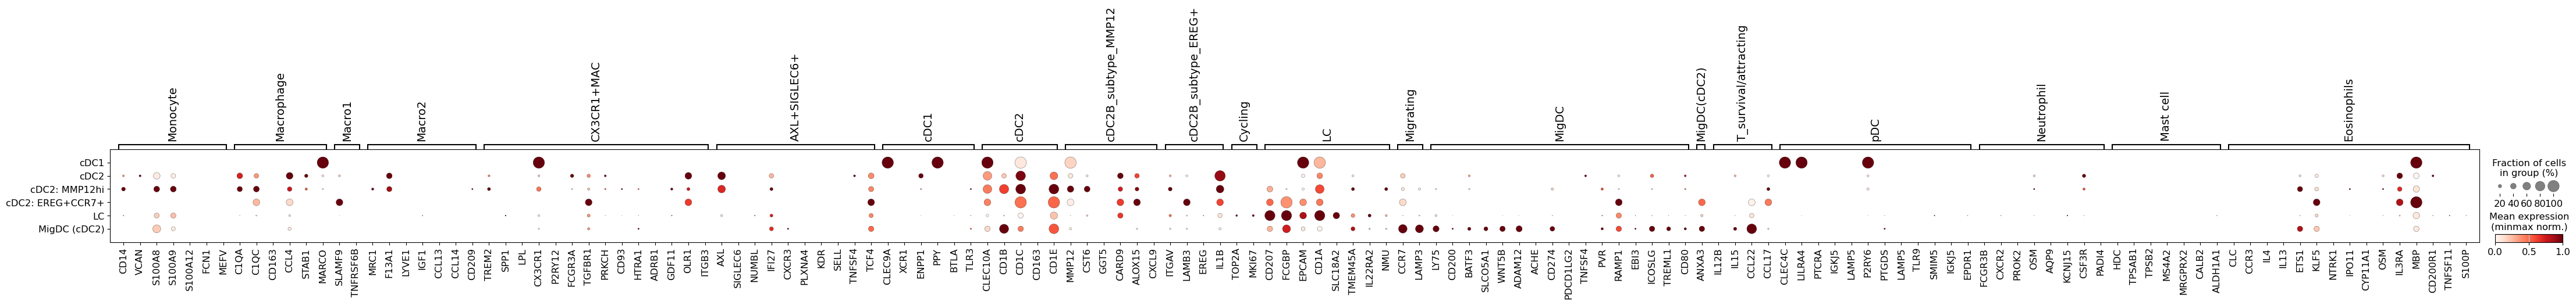

In [67]:
mac_markers={ 'Monocyte': ['CD14', 'VCAN', 'S100A8', 'S100A9', 
              'S100A12', "FCN1",'MEFV'], #"FCGR3A"
 #'Monocyte1': ['SERPINB2', 'MTF1', 'PTGER2'],
 #'Monocyte2': ['aaFCGR1A', 'SYT1', 'ASGR1', 'PRAM1', 'CCR2'],
# 'Mono_KC': ['KRT16', 'EGFR'],
 'Macrophage': ['C1QA', 'C1QC',  'CD163', 'CCL4', "STAB1",'MARCO', ],
      'Macro1': ['SLAMF9', 'TNFRSF6B',#"CXCL5", #"IL24"
                # "CCL24"
                ],

 'Macro2': ['MRC1','F13A1', "LYVE1","IGF1", "CCL13", 'CCL14', "CD209"],
 #'T': ['CD3E', 'CD96', 'TRBC1'],
 #'Macro_NEU4/LRRC32': ['CCL4L2', 'CCRL2', 'ACHE', 'NEU4', 'IL23A', 'CD40'],
# 'TREM2+ADAMDEC1+': ['TREM2', 'CXCL5', 'EPHB2', 'STAC', 'FAM20C'],
 'CX3CR1+MAC': ['TREM2', 'SPP1',  "LPL", 'CX3CR1', #'ADRB1', 
              # "KCNQ3"#"UNC5B", "GPR34", "SMAD7",  "CD72", "TGFBR1", 
             #  "CD9",
               
                "P2RY12", #'ADAMDEC1',
                'FCGR3A', 
                'TGFBR1', 'PRKCH', 'CD93', 'HTRA1', "ADRB1",
                'GDF11', 'OLR1', 'ITGB3'
               ],
             'AXL+SIGLEC6+': ['AXL', 'SIGLEC6', 'NUMBL', 'IFI27', 'CXCR3', 'PLXNA4', 'KDR', "SELL",
                             "TNFSF4", "TCF4"],

 'cDC1': ['CLEC9A', 'XCR1', "ENPP1", "PPY", "BTLA", "TLR3"],
             #"Mature cDC1": ["ITGAE", "CD8A"],
 'cDC2': ['CLEC10A', 'CD1B', 'CD1C', "CD163", 'CD1E', # 'CD5', 
          #'SPIB', 'TNFSF4', 'TSPAN2'
         ],

             'cDC2B_subtype_MMP12': ['MMP12', "CST6", "GGT5", "CARD9",  "ALOX15", "CXCL9",#'CROCC',
                   ],
              'cDC2B_subtype_EREG+': ["ITGAV","LAMB3", 
 "EREG",'IL1B', #'CROCC',
                                       #"SATB1",
                                     # "EHD1", "LUCAT1", "ITGAV", "OLR1", "TNFRSF4", "DOT1L", "DOCK4",
          #    "ADA", "MMP19", "ELK1", "LAMB3", "MIR3142HG", "GPR35",   "ISG20", "CXCL3", "MMP9",  
                   ],
                    "Cycling": ["TOP2A", "MKI67"],
             # 'MoDC': ["PLK2", "KLF2", "THBS1"
             #     #'THBS1',  'C1QTNF1', "INHBA", "TNFRSF4"
             # ],

 'LC': ['CD207','FCGBP', "EPCAM", 'CD1A', "SLC18A2", "TMEM45A", "IL22RA2","NMU" #"CLEC4A"
       ],
              'Migrating': ['CCR7', 'LAMP3',  ], 

 'MigDC': ['LY75', "CD200",  "BATF3",'SLCO5A1', 'WNT5B', 'ADAM12', "ACHE",
           "CD274", "PDCD1LG2",  "TNFSF4", "PVR", "RAMP1" , "EBI3","ICOSLG",
          "TREML1", "CD80", ],  #'ST8SIA1', 'CCL19', "CCL17", "CCL22",
         
     #"TFPI", "SERINC2", #"IL10",
          #'LILRA1', 'LILRA2'
             "MigDC(cDC2)": ["ANXA3"],
             "T_survival/attracting": ["IL12B", "IL15",  "CCL22", "CCL17", ],
 'pDC': ['CLEC4C',  #'IL3RA', 'TNFRSF21', 
         
         'LILRA4', 'PTCRA', 'IGKJ5', 'LAMP5', "P2RY6",# "ITGAE", 
         "PTGDS",'LAMP5', 'TLR9',  'SMIM5', 'IGKJ5', 'EPDR1',],
 'Neutrophil': [#'CXCL8',
     'FCGR3B', "CXCR2", "PROK2", "OSM",  #KCNJ15, ADGRG3
        "AQP9",
    "KCNJ15",
 
    #"CXCL12",
    #"LILRB4",
    #"SLIT3",
    "CSF3R",
    #"TNFSF13B",
   # "TNFSF10",
    "PADI4",
                # "MPO"
               ], 
                      #(adata.obs[CATEGORY]== "Neutrophil")]
              "Mast cell": [#"HPGDS", "KIT", "HPGD",
                    "HDC", #"GATA2",   
                    "TPSAB1", "TPSB2", "MS4A2","MRGPRX2",
                              "CALB2", "ALDH1A1" #"CAVIN2", "HEY1"
                ],
          "Eosinophils": [ "CLC", "CCR3",#"CCL23",    #"PTGDR2", "P2RY1", 
                         
                             "IL4",
    "IL13",
    "ETS1",
    "KLF5",
    "NTRK1",
 
    "IPO11",
    "CYP11A1",

    "OSM", 
   "IL3RA","MBP","CD200R1",    "TNFSF11",   "S100P",
                            
                           ], 
            #"OTHER": ["SECISBP2L"],
      
      
            }

adata_i.obs[CATEGORY] = adata_i.obs[CATEGORY].astype("category").cat.remove_unused_categories()

sc.pl.dotplot(adata_i, 
              mac_markers,
              groupby=CATEGORY, 
              dendrogram=False, 
                standard_scale="var",
                                         colorbar_title="Mean expression\n(minmax norm.)",
                    # save="myeloid_scrna.pdf"
             )

# KC interfollicular

In [68]:
adata_i = adata_mappeddata[(adata_mappeddata.obs[CATEGORY].str.startswith("KC"))#|
              # (adata.obs[CATEGORY].str.startswith("KC"))
               ]
adata_i = adata_i[~adata_i.obs[CATEGORY].str.startswith("KC_")
               ]

In [69]:

desired_order = ['KC1','KC1/2','KC1/2_cycling',"KC1-2_cycling",
 'KC2',     'KC2/3_cycling',    
    'KC3',
             'KC4',
     
           'KC5',
        'KCinflamm_basal',
 'KCinflamm_int',
                  'KCinflamm_late','KCinflamm_int/late',
 'KCinflamm_cycling',

               
 'KC_HF: Basal_LGR5+','KC_HF: Basal LGR5+',
 'KC_HF: Basal_NPNT+','KC_HF: ORS-0',
'KC_HF: ORS 1/2',
 'KC_HF: ORS/CL','KC_HF_CL', 

 'KC_HF: IRS+HS', 'KC_HF_IRS/HS', 'KC_HF: IRS',
'KC_HF: HS', 'KC_HF_cycling',
                                 'KCinflamm_Sebocyte_basal',  'KC_Sebocyte_basal','KC_Sebocyte_int',
                 'KC_Sebocyte_duct_basal/outer',
'KC_Sebocyte_PPARG+_basal/outer',
'KC*_Sebocyte',



 'KC_Sebocyte_inner','KC_Sebocyte_inner2',
'KC_Sebocyte_inner1','KC_Sebocyte_cycling','KC_Sebocyte_duct_inner',

'KC_Sebocyte_duct_outer', #'KC_Sebocyte_duct_basal/outer',
'KC_Sebocyte_PPARG+_basal',

'KC_Sebocyte_PPARG+_basal_cycling',

'KChf/cycling/ KC_Sebocyte_PPARG+_inner',
                
 'Sweat gland channel outer',    'Sweat gland channel outer_cycling',  'Sweat gland channel inner',
 'Sweat gland','KC_SC: LGR6+ACTA2+',
                 
                 
                
'KC/lowq_mastcell','KC_cycling/Mac_doublet','KC/lowq_melanocyte/T','KC*',
                 'KC_Outlier?','KC/lowq_mac_doublet','Sweat gland_plasma doublet'
,'KChf_cycling', "missing", "KC"





]

if not pd.api.types.is_categorical_dtype(adata_i.obs[CATEGORY]):
    adata_i.obs[CATEGORY] = adata_i.obs[CATEGORY].astype('category')

if not pd.api.types.is_categorical_dtype(adata_i.obs[CATEGORY]):
    adata_i.obs[CATEGORY] = adata_i.obs[CATEGORY].astype('category')

missing_data = 0
for x in list(adata_i.obs[CATEGORY].unique()):
    if x not in desired_order:
        print(x)
        missing_data +=1
if missing_data != 0:
    stop
        
        
# Set the categories in the desired order
adata_i.obs[CATEGORY] = pd.Categorical(
    adata_i.obs[CATEGORY],
    categories=desired_order,
    ordered=True
)
 

/tmp/ipykernel_2462884/269290774.py:52: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata_i.obs[CATEGORY]):
/tmp/ipykernel_2462884/269290774.py:55: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata_i.obs[CATEGORY]):
/tmp/ipykernel_2462884/269290774.py:68: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[CATEGORY] = pd.Categorical(


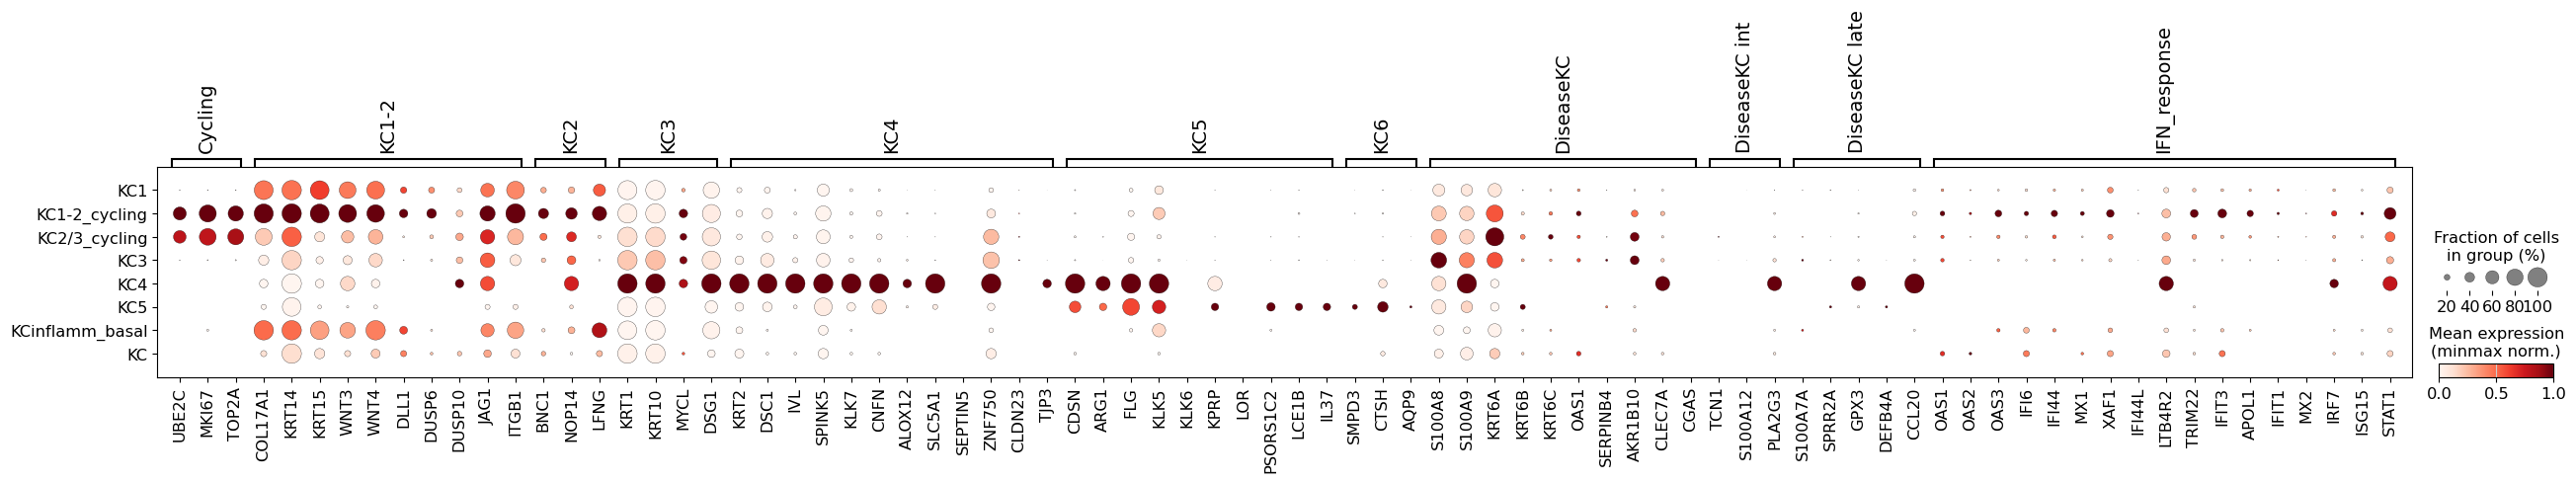

In [70]:
kc_markers={
   "Cycling": ['UBE2C', 'MKI67', "TOP2A",# "BIRC5",
                                #  "MYBL2", "TPX2"
                                  ], 'KC1-2': ['COL17A1', "KRT14",   'KRT15', "WNT3", "WNT4", 
                                        "DLL1", 'DUSP6',"DUSP10", "JAG1", "ITGB1"
                                              
                                              ],
 #   "KRT9": ["KRT9"],
 'KC2': ['BNC1', 'NOP14',         "LFNG",],
 'KC3': ['KRT1', 'KRT10', "MYCL", "DSG1"],
 'KC4': ['KRT2', 'DSC1', 'IVL', 'SPINK5', 'KLK7',  "CNFN", "ALOX12", "SLC5A1" ,"SEPTIN5", "ZNF750", "CLDN23", "TJP3"
         ],
 'KC5': ["CDSN","ARG1",'FLG',"KLK5" , "KLK6",  "KPRP", 'LOR', 'PSORS1C2', 'LCE1B', "IL37",],
     "KC6": ['SMPD3', 'CTSH',  "AQP9" ],
          
    
 'DiseaseKC': ['S100A8',
  'S100A9',
  'KRT6A',
  'KRT6B',
  'KRT6C',
  'OAS1',  'SERPINB4','AKR1B10', "CLEC7A",# "TLR3", "TLR5", 
              # "STAT1", 'STAT2', 'IRF7',
               "CGAS", 
              ],
# 'DiseaseKC basal': ['RTP4',"MX1",],
  "DiseaseKC int": [ "TCN1", "S100A12", "PLA2G3" ], 
 'DiseaseKC late': [
  'S100A7A',
  'SPRR2A',
  'GPX3',"DEFB4A", "CCL20"
 #"SERPINB11",
 ],
    "IFN_response":  ["OAS1", "OAS2", "OAS3", #"IFI27",
                      "IFI6",  "IFI44",
                "MX1", #"NMI", 
                      "XAF1", "IFI44L", "LTB4R2",
               "TRIM22", "IFIT3", "APOL1", "IFIT1",
            
               'MX2', 'IRF7', 'ISG15', 'STAT1'],
 



}

adata_i.obs[CATEGORY] = adata_i.obs[CATEGORY].astype("category").cat.remove_unused_categories()
#adata_5k_i.obs[CATEGORY] = adata_5k_i.obs[CATEGORY].astype("category").cat.remove_unused_categories()

 
sc.pl.dotplot(
    adata_i,
    remove_markers(kc_markers),
    groupby=CATEGORY,
    standard_scale="var",
    dendrogram=False,
                               colorbar_title="Mean expression\n(minmax norm.)",

     # save="kc_scrna.pdf"
    
) 

 
 

# kc appendage

In [71]:
adata_i = adata_mappeddata[(adata_mappeddata.obs[CATEGORY].str.startswith("KC_"))|
            (adata_mappeddata.obs[CATEGORY].str.startswith("Sweat"))
               ]

adata_i.obs[CATEGORY].value_counts()


scanvi_predictions
Sweat gland channel outer    103
KC_Sebocyte_DuctOuter         54
KC_Sebocyte_DuctInner         38
Sweat gland channel inner      9
KC_Sebocyte_GlandBasal         1
Name: count, dtype: int64

In [72]:
from collections import OrderedDict  

desired_order = [
    'KC1', 'KC1/2', 'KC1/2_cycling', 'KC1-2_cycling',
    'KC2', 'KC2/3_cycling', 'KC3', 'KC4', 'KC5',
    'KCinflamm_basal', 'KCinflamm_int', 'KCinflamm_late',
    'KCinflamm_int/late', 'KCinflamm_cycling',
    
 'KC_HF: HFSC',
    'KC_HF: Basal_LGR5+', 'KC_HF: Basal LGR5+','KC_HF: ORS-Bulb/infundibulum', 'KC_HF_SPON2',
    'KC_HF: SPON2+', 
    
    'KC_HF: Basal_NPNT+', 'KC_HF: ORS-0', 'KC_HF: ORS0',
    'KC_HF: ORS1', 'KC_HF: ORS2',   'KC_HF: ORS2i', 'KC_HF: ORS 1/2',
    'KC_HF: ORS1/2', 'KC: HF ORS1/2', 'KC_HF: ORS_cycling',
    'KC_HF: ORS/CL', 'KC_HF_CL',
     'KC_HF: ORS_junction', 
      'KC_HF: IRS0',    'KC_HF: IRS1',

    'KC_HF: IRS+HS', 'KC_HF_IRS/HS',   'KC_HF: IRS_Cuticle', 'KC_HF: IRS',
       'KC_HF: IRS_Sebo_doublet?',
    'KC_HF: IRS_cycling', 'KC_HF: Matrix', 'KC_HF: IRS_TCHH+',
    'KC_HF: HS', 'KC_HF: HS1',  'KC_HF_cycling', 'KC_HF: HS2',    'KC_HS: HS_TRPV1+',
    'KCinflamm_Sebocyte_basal', 'KC_Sebocyte_basal',
    'KC_Sebocyte_duct_basal/outer', 'KC_SebocyteDuct_Outer',
    'KC_Sebocyte_duct_outer', 'KC_SebocyteDuct_Outer-LOWQ',
    'KC*_Sebocyte',
    'KC_Sebocyte_inner', 'KC_Sebocyte_inner2',
    'KC_Sebocyte_inner1', 

      'KC_Sebocyte_DuctOuter',
      'KC_Sebocyte_DuctInner', 
    'KC_Sebocyte_duct_inner', 'KC_SebocyteDuct_Inner',
    'KC_SebocyteDuct_Outer/HF_Junction',
    'KC_SebocyteDuct_Outer/HF_junction2','KC_SebocyteDuct_Outer/HF_junction', 
 'KC_Sebocyte_DuctInner_Junction',

     'KC_Sebocyte_GlandBasal',
    'KC_Sebocyte_PPARG+_basal', 'KC_SebocyteGland_Outer','KC_SebocyteGland_outer',
    'KC_Sebocyte_PPARG+_basal_cycling',
    'KC_Sebocyte_PPARG+_basal/outer', 'KC_Sebocyte_int',
    'KChf/cycling/ KC_Sebocyte_PPARG+_inner','KC_Sebocyte_cycling',
      'KC_Sebocyte_GlandInner',
    'Sweat gland channel outer', 'Sweat gland channel cycling',
    'Sweat gland channel inner', 'Sweat gland',
    'KC_SC: LGR6+ACTA2+', 'Sweat gland Myoepithelial',
    'Sweat gland myoepithelial',
    'KC/lowq_mastcell', 'KC_cycling/Mac_doublet',
    'KC/lowq_melanocyte/T', 'KC*', 'KC_Outlier?',
    'KC/lowq_mac_doublet', 'Sweat gland_plasma doublet',
    'KChf_cycling', 'Sweat gland_cycling',
    "missing",'ASIC2+_Mechanoreceptor', 'Merkel cell',








]

# ------------------------------------------------------------------
# 2.  Remove duplicates *without* changing order
# ------------------------------------------------------------------
desired_order = list(dict.fromkeys(desired_order))  # or OrderedDict.fromkeys

# ------------------------------------------------------------------
# 3.  Ensure column is categorical
# ------------------------------------------------------------------
if not pd.api.types.is_categorical_dtype(adata_i.obs[CATEGORY]):
    adata_i.obs[CATEGORY] = adata_i.obs[CATEGORY].astype("category")

# ------------------------------------------------------------------
# 4.  Sanity-check: all data labels must be in desired_order
# ------------------------------------------------------------------
missing_labels = set(adata_i.obs[CATEGORY].unique()) - set(desired_order)
if missing_labels:
    raise ValueError(f"Labels present in data but missing from desired_order:\n{missing_labels}")

# ------------------------------------------------------------------
# 5.  Apply the ordering and drop unused categories
# ------------------------------------------------------------------
adata_i.obs[CATEGORY] = pd.Categorical(
    adata_i.obs[CATEGORY],
    categories=desired_order,
    ordered=True,
)
adata_i.obs[CATEGORY] = adata_i.obs[CATEGORY].cat.remove_unused_categories()

adata_i.obs[CATEGORY].value_counts()



/tmp/ipykernel_2462884/899363897.py:71: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata_i.obs[CATEGORY]):
/tmp/ipykernel_2462884/899363897.py:84: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[CATEGORY] = pd.Categorical(


scanvi_predictions
Sweat gland channel outer    103
KC_Sebocyte_DuctOuter         54
KC_Sebocyte_DuctInner         38
Sweat gland channel inner      9
KC_Sebocyte_GlandBasal         1
Name: count, dtype: int64

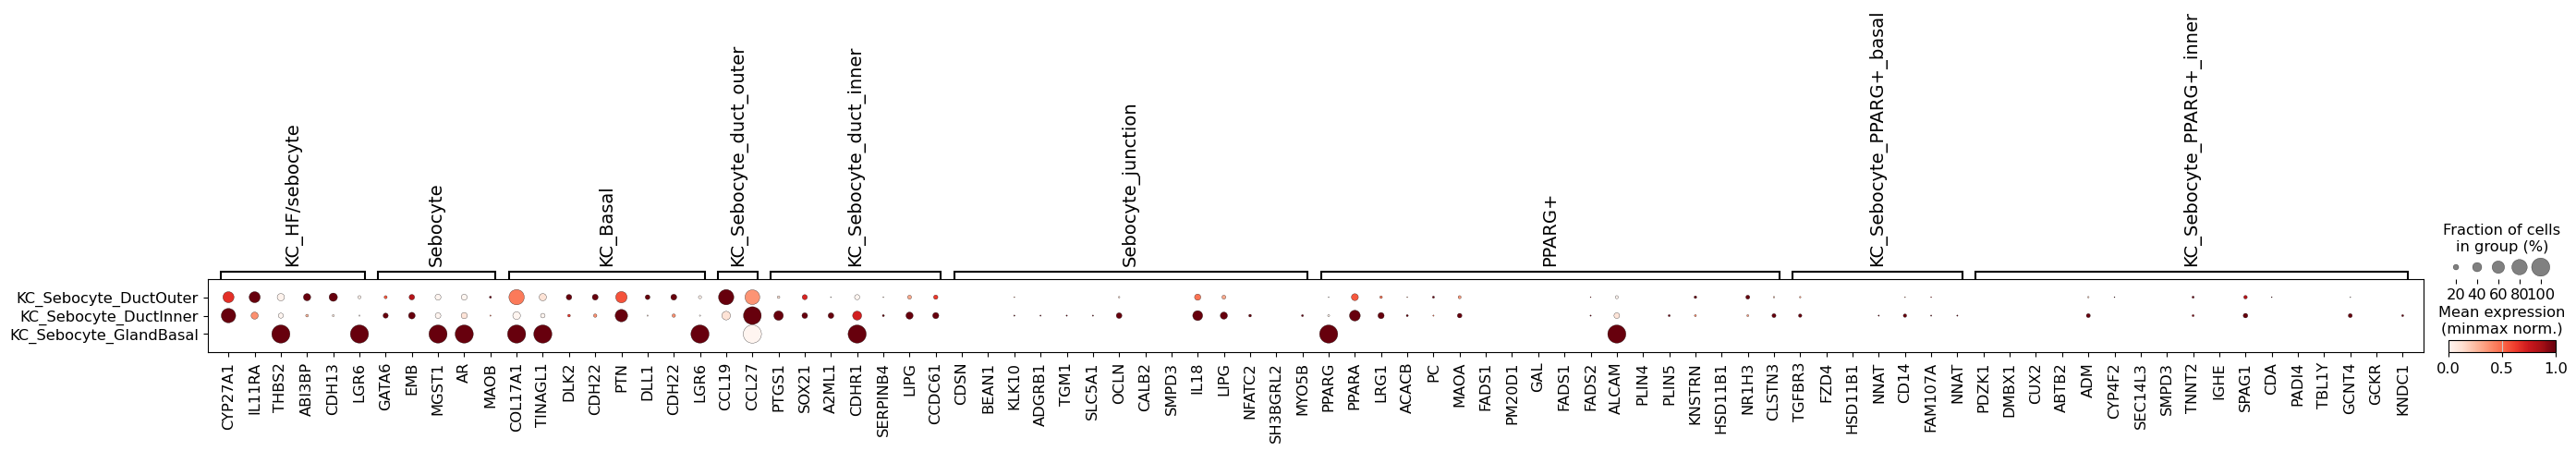

In [73]:
kc_markers={         "KC_HF/sebocyte": [ "CYP27A1",  "IL11RA", "THBS2", "ABI3BP", "CDH13", "LGR6",],
 'Sebocyte': [ "GATA6",  "EMB",   'MGST1', "AR", "MAOB",
                 #"FST", "ANGPTL2",  
                ],
 'KC_Basal': ['COL17A1',    "TINAGL1",  "DLK2",  "CDH22" , "PTN", "DLL1",  'CDH22', "LGR6", ],
 #   "KRT9": ["KRT9"],
 #'KC2': ['BNC1', 'NOP14'],
#  #'KC_Int': ['MYCL', 'ALOX12', "CDSN",],
#  'KC4': ['KRT2', 'DSC1', 'IVL', 'SPINK5', 'KLK7',  "CNFN", "ALOX12", "SLC5A1" ,"SEPTIN5", "ZNF750", "CLDN23", "TJP3"
#          ],
#  'KC5': ["CDSN","ARG1",'FLG',"KLK5" , "KLK6",  "KPRP", 'LOR', 'PSORS1C2', 'LCE1B', "IL37",],
#      "KC6": ['SMPD3', 'CTSH',  "AQP9" ],
        
    
#  # 'DiseaseKC': ['S100A8',
 #  'S100A9',
 #  'KRT6A',
 #  'KRT6B',
 #  'KRT6C',
 #  'OAS1',  'SERPINB4','AKR1B10', "CLEC7A",# "TLR3", "TLR5", 
 #              # "STAT1", 'STAT2', 'IRF7',
 #               "CGAS", 
 #              ],

 

   
         'KC_Sebocyte_duct_outer': ["CCL19", "CCL27",#"CCL22",
                 #"VCAM1", "IRF1", "ITGB1", 
                                   ],
    
     'KC_Sebocyte_duct_inner': ['PTGS1', "SOX21", "A2ML1", "CDHR1", #"GATA6",
                                "SERPINB4", "LIPG", "CCDC61",  ],
            "Sebocyte_junction": ["CDSN", "BEAN1","KLK10", "ADGRB1", "TGM1", "SLC5A1", "OCLN", "CALB2",
                # "LGALSL",
                  "SMPD3",  "IL18","LIPG", "NFATC2", #"SERPINA3", 
                  "SH3BGRL2",
                 "MYO5B"],
# 'KC_Sebocyte_duct_outer_cycling': [''],
 #'KC_Sebocyte_duct_outer_inflamm': ['CFB', "VCAM1", "ADAM8", "JAK3", "MX1", "CXCR4", "CIITA", "STAT5A"],
            "PPARG+": [ 'PPARG',  "PPARA", "LRG1", "ACACB", "PC", 
                             "MAOA", "FADS1", "PM20D1",'GAL',  "FADS1", "FADS2", 'ALCAM',"PLIN4",
                      "PLIN5",  "KNSTRN", "HSD11B1",  "NR1H3", "CLSTN3",
                      ],
     'KC_Sebocyte_PPARG+_basal': [    "TGFBR3", "FZD4", "HSD11B1" ,  "NNAT", "CD14", "FAM107A",  "NNAT",],
 'KC_Sebocyte_PPARG+_inner': [  "PDZK1",  "DMBX1",
                              "CUX2", "ABTB2", "ADM", "CYP4F2", "SEC14L3", "SMPD3", "TNNT2",
                            "IGHE", "SPAG1", "CDA", "PADI4", "TBL1Y", "GCNT4", "GCKR", "KNDC1"
                             ],
#      'Channel_general': [ 'RUNX3', 'CCN3', "MYLPF", #"FGF7"
#                         ],
        
    

 #"Gland": [ ],
#     "KC*": ['ZNF581', 'HILPDA', 'ANG', "DIABLO"],
               
#    # "Merkel": ["ATOH1", "KRT20"],
#   #  "ADIPO:": ["CEACAM1", "ADIPOQ", "CD36"]
#     "Cycling": ['UBE2C', 'MKI67', "TOP2A",# "BIRC5",
#                                 #  "MYBL2", "TPX2"
#                                   ], 
    
#     "IFN_RESPONSE":  ["OAS1", "OAS2", "OAS3", #"IFI27",
#                       "IFI6",  "IFI44",
#                 "MX1", #"NMI", 
#                       "XAF1", "IFI44L", "LTB4R2",
#                "TRIM22", "IFIT3", "APOL1", "IFIT1",
            
#                ] ,
}

adata_ii=adata_i[(adata_i.obs[CATEGORY].str.startswith("KC_S"))|
                (adata_i.obs[CATEGORY].str.startswith("KCinflamm_S"))
                 #(adata_i.obs[CATEGORY].str.startswith("KChf"))
                ]
sc.pl.dotplot(
    adata_ii,
    kc_markers,
    groupby=CATEGORY,
    standard_scale="var",
    dendrogram=False,
                           colorbar_title="Mean expression\n(minmax norm.)",

    #vmax=1,
#     categories_order=['KC_Sebocyte_duct_basal/outer', 'KC_Sebocyte_duct_inner',
#  'KC_Sebocyte_PPARG+_basal/outer',
#  'KC_Sebocyte_PPARG+_basal_cycling',
# ]
) 

In [75]:
# adata_ii

View of AnnData object with n_obs × n_vars = 0 × 32732
    obs: 'sample_id', 'barcode', 'GSE', 'Site_status', 'Patient_status', 'dataset_id', 'lvl5_annotation', 'Mapping_status', 'scanvi_predictions'
    uns: 'neighbor_20', 'umap', 'Mapping_status_colors', 'lvl5_annotation_colors', 'scanvi_predictions_colors'
    obsm: 'X_scanvi', 'X_umap'
    obsp: 'neighbor_20_connectivities', 'neighbor_20_distances'

In [74]:
ORDER=[  'KC_HF: HFSC', 'KC_HF: SPON2+',
       'KC_HF: ORS0',
 'KC_HF: ORS1',
 'KC_HF: ORS2',
       
 'KC_HF: ORS_junction','KC_HF: ORS_cycling',
      





      
       'KC_HF: IRS0',
 'KC_HF: IRS1',
 'KC_HF: IRS_Cuticle', 'KC_HF: HS', 'KC_HF: Matrix', 
      ]

kc_markers={
#  'KC1-2': ['COL17A1',  ],
#  #   "KRT9": ["KRT9"],
#  # #'KC2': ['BNC1', 'NOP14'],
#  # 'KC3': ['KRT1', 'KRT10', "MYCL", "DSG1"],
#  # 'KC4': ['KRT2', 'DSC1', 'IVL', 'SPINK5', 'KLK7',  "CNFN", "ALOX12", "SLC5A1" ,"SEPTIN5", "ZNF750", "CLDN23", "TJP3"
#  #         ],
#  # 'KC5': ["CDSN","ARG1",'FLG',"KLK5" , "KLK6",  "KPRP", 'LOR', 'PSORS1C2', 'LCE1B', "IL37",],
         
    

   
#             "KC_HF/sebocyte": [ "CYP27A1",  "IL11RA", "THBS2", "ABI3BP", "CDH13", "LGR6",],
#          "KC_HF": ["LHX2", "RARRES2", "KRT15",],

         
     'KC_HF: LGR5+': ['LGR5', 'GLI2', "CNTN6",'IL31RA',
                             "COMP", "MEST", "RAI14", "AEBP1", "OLFML3", "LTBP2", "ACTA2"
                             ],
    
        "SPON2":  [  'INHBA', "SPON2", "IGFBP5", "WNT5B", "DIO2", "F2R", "BAALC","NPY1R",#"EDIL3", 
                  'WNT5B', 'FOXI3', 'FBN3', 'MBOAT1'
                   
                  
                  ],
        'KC_HF: ORS0': [ "CD200", 'NPNT',  "GREM1", ],
    
                "KC_HF: NPNT+": ['PCDH20', #'SERPINF1', 
                                 'FBLN2',
                                 #"WIF1"
                                ],


            
 'KC_HF: ORS/CL': ['KRT75', 'PARM1', "CBLN2", "SERPINA3", "ADGRB1"],
   #      "KC6": ['SMPD3', 'CTSH',  "AQP9" ],
        "Junction": ["SLC15A1", "SCNN1A", #"GATA6",
                     "SLCO2B1", "TYMP", "GPT"],

#      'KC_HF: inner': ['KRT85', 'KRT35', 'KRT25', 'PADI3', 'TCHH',  "DLX2",
#                  'MSI1',
                 

#   #'SOX11',
#                  ],
    
    'KC_HF: IRS0':    ["SHH", "TGFA", "GDA", "HPGD", "SMOX",
        "GSDMC", 
      "CDA"],
      'KC_HF: IRS1':    [ "FLRT3", "NT5E", "GPR37", "ABCA4", "CRNN",
  'MYCN',],


     
    "Cuticle":[
        "KCNN4",  "PADI2", "B3GAT1", "IL6R", 
        "SERPINA3", "KLK6", "TRPV1", "SLAMF7",
       "IL37", "CALB2", "GABRP",
        # "TGFA", "GDA", "HPGD", "SMOX",
      #  "GSDMC", 
      #  "POU5F1", "CDA"
    ],
      "Cycling": ['UBE2C', 'MKI67', "TOP2A",# "BIRC5",
                                #  "MYBL2", "TPX2"
                                  ], 
    "HS": ["TGM1", "KRT82", "KRT35", "KRT23",
          "RETREG1", "F12", "VSNL1",# "GNAI1", "REEP6","PARM1", "CD200",
           "HOXC13", "LEF1",
          ],
 

#     'Sebocyte': [ "GATA6",    'MGST1', "AR","PTN", 
#                  "FST", "ANGPTL2",],


#  'LGR6+': ['LGR6', 'PCP4', 'ACTA2', 'TAGLN', 'MYH11', 'CHRM3', #'STAC2',
#            'MPPED2',#'KCNQ5',
#           'LTBP2', #'IGFBP2', 
#            'TGFB1I1',#'MCAM',
#            'KCNMB1', 'SMOC2', 'JAM3', "CD200", "FBLN2"],

 #"Gland": [ ],
  #  "KC*": ['ZNF581', 'HILPDA', 'ANG', "DIABLO"],
               

}

adata_ii=adata_i[(adata_i.obs[CATEGORY].str.startswith("KC_HF"))|
                       (adata_i.obs[CATEGORY].str.startswith("KC_HS"))
                      
                      ]
sc.pl.dotplot(
    adata_ii,
                  kc_markers,
    groupby="lvl5_annotation",
    standard_scale="var",
    dendrogram=False,

                           colorbar_title="Mean expression\n(minmax norm.)",


# ]
) 
 

ValueError: max() arg is an empty sequence

ValueError: Image size of 146595x207 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 1444x125 with 2 Axes>

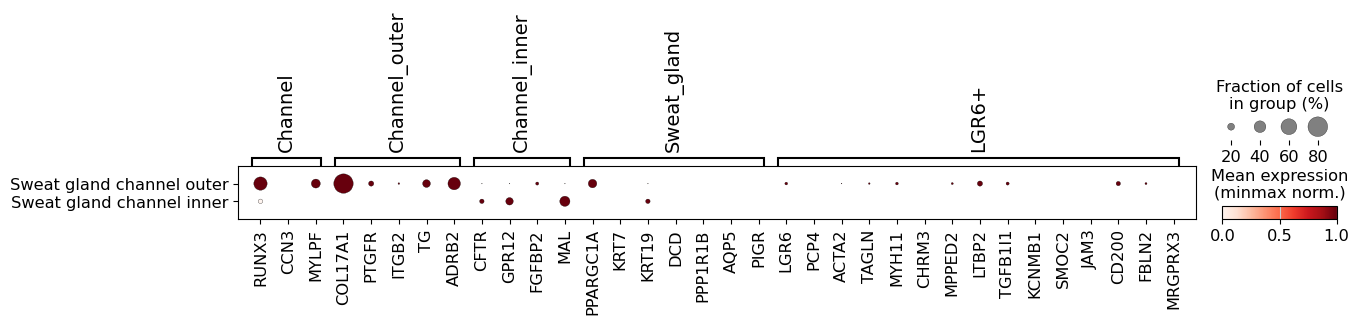

In [76]:
kc_markers={     'Channel': [ 'RUNX3', 'CCN3', "MYLPF", #"FGF7"
                        ],
        
    "Channel_outer":  ['COL17A1', "PTGFR", "ITGB2", "TG", "ADRB2"],
            "Channel_inner": [ "CFTR",  #"CRHR1",
                              "GPR12", 'FGFBP2', 'MAL', ],
    
 'Sweat_gland': ["PPARGC1A",'KRT7', 'KRT19','DCD', #"SLC12A2",
                 "PPP1R1B", "AQP5", "PIGR"], 
    
                               
 'LGR6+': ['LGR6', 'PCP4', 'ACTA2', 'TAGLN', 'MYH11', 'CHRM3', #'STAC2',
           'MPPED2',#'KCNQ5',
          'LTBP2', #'IGFBP2', 
           'TGFB1I1',#'MCAM',
           'KCNMB1', 'SMOC2', 'JAM3', "CD200", "FBLN2",  "MRGPRX3"],
    

 #"Gland": [ ],
    #"KC*": ['ZNF581', 'HILPDA', 'ANG', "DIABLO"],
               
   # "Merkel": ["ATOH1", "KRT20"],
  #  "ADIPO:": ["CEACAM1", "ADIPOQ", "CD36"]

}

adata_ii=adata_i[adata_i.obs[CATEGORY].str.startswith("Sweat")|
                adata_i.obs[CATEGORY].str.startswith("KChf")|
                                 adata_i.obs[CATEGORY].str.startswith(   'KC_SC')

              
               
               ]
sc.pl.dotplot(
    adata_ii,
              kc_markers,
    groupby=CATEGORY,
    standard_scale="var",
    dendrogram=False,
                               colorbar_title="Mean expression\n(minmax norm.)",

               # save="sweat_scrna.pdf"

) 

 

In [81]:
# kc_markers={     'Channel': [ 'RUNX3', 'CCN3', "MYLPF", #"FGF7"
#                         ],
        
#     "Channel_outer":  ['COL17A1', "PTGFR", "ITGB2", "TG", "ADRB2"],
#             "Channel_inner": [ "CFTR",  #"CRHR1",
#                               "GPR12", 'FGFBP2', 'MAL', ],
    
#  'Sweat_gland': ["PPARGC1A",'KRT7', 'KRT19','DCD', #"SLC12A2",
#                  "PPP1R1B", "AQP5", "PIGR"], 
    
                               
#  'LGR6+': ['LGR6', 'PCP4', 'ACTA2', 'TAGLN', 'MYH11', 'CHRM3', #'STAC2',
#            'MPPED2',#'KCNQ5',
#           'LTBP2', #'IGFBP2', 
#            'TGFB1I1',#'MCAM',
#            'KCNMB1', 'SMOC2', 'JAM3', "CD200", "FBLN2",  "MRGPRX3"],
    

#  #"Gland": [ ],
#     #"KC*": ['ZNF581', 'HILPDA', 'ANG', "DIABLO"],
               
#    # "Merkel": ["ATOH1", "KRT20"],
#   #  "ADIPO:": ["CEACAM1", "ADIPOQ", "CD36"]

# }

# adata_ii=adata_i[adata_i.obs[CATEGORY].str.startswith("Sweat")|
#                 adata_i.obs[CATEGORY].str.startswith("KChf")|
#                                  adata_i.obs[CATEGORY].str.startswith(   'KC_SC')

              
               
#                ]
# sc.pl.dotplot(
#     adata_ii,
#               remove_markers(kc_markers),
#     groupby=CATEGORY,
#     standard_scale="var",
#     dendrogram=False,
#                                colorbar_title="Mean expression\n(minmax norm.)",

 
# ) 


# vasc

In [78]:
adata_i = adata_mappeddata[ (adata_mappeddata.obs[CATEGORY].str.startswith("Peri"))|
                (adata_mappeddata.obs[CATEGORY].str.startswith("LE"))|
                (adata_mappeddata.obs[CATEGORY]=="Smooth muscle")|
                (adata_mappeddata.obs[CATEGORY]=="Skeletal muscle")|
                (adata_mappeddata.obs[CATEGORY]=="Satellite muscle")|
                               (adata_mappeddata.obs[CATEGORY].str.startswith("VE"))
              
               
               ]
adata_i.shape
 

(0, 32732)

In [79]:

# ------------------------------------------------------------------
# 1.  Desired order (drop duplicates without shuffling)
# ------------------------------------------------------------------
desired_order = list(OrderedDict.fromkeys([
    'Pericyte1_CCL19+', 'Pericyte1',
    'Pericyte2_CASQ2+', 'Pericyte2 (VSMC)', 'Pericyte2_VSMC',
    'Smooth muscle',
    'VE1_ADAMTS6_Art', 'VE1_Art', 'VE1_HEY1_art',
    'VE2', 'VE3_SELPhi_CCL23+', 'VE3_SELPhi_venule', 'VE3_Ven',
    'VE3_SELPhi', 'VE3_APLNhi', 'VE3_APLNhi_prolif', 'VE3_Prolif_APLN+', 'VE4_Cap_APLN+',
    'VE3_SELP_CD36+PPARG+', 'VE3_Ven_APLN+',
    'VE4_Cap', 'VE4_cap_CA4', 'VE4_Cap_CA4+',
    'LE1', 'LE',
    'Skeletal muscle', 'Satellite muscle',
    'VE*/pericyte',
    'VE3_CA4hi_cap', 'VE_lowq', 'VE_APLN_PLA1A_PTGDS/ F3 merge',
    'VE1', 'VE3_SELPhi_CD300LG', 'VE3/LE',
    'Vasc_Mural_doublet', 'VE1_GJA5hi',
    'Pericyte*', 'VE3_SELPhi_5', 'Pericyte/T doublet', 'Pericyte_LOWQ?',
    "missing"
]))

# ------------------------------------------------------------------
# 2.  Make column categorical & drop empty categories
# ------------------------------------------------------------------
adata_i.obs[CATEGORY] = adata_i.obs[CATEGORY].astype("category")
adata_i.obs[CATEGORY] = adata_i.obs[CATEGORY].cat.set_categories(desired_order, ordered=True)
adata_i.obs[CATEGORY] = adata_i.obs[CATEGORY].cat.remove_unused_categories()



/tmp/ipykernel_2462884/3729714061.py:26: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[CATEGORY] = adata_i.obs[CATEGORY].astype("category")


In [80]:
vasc_markers_new = {"Peri": ["PDGFRB", "RGS5", "TAGLN", "ACTA2", "ADRA2A", "NOTCH3", "CCL8"],
                    "Peri1": [ "CCL19", "ANPEP", "PTGES", "WNT6", "NGFR", "ADAMTS2", "COL23A1", "TMEM119", "ADCYAP1R1"],
                    "Peri2": ["CASQ2", "MEF2B", "MUSTN1", "MYH11", "SGCA", "USP2","PLN", "KCNA5" ,"SPEG", "NTRK3", "MYOCD", "ENTPD3", "KCNAB1", "CPED1", "ITGA8", "RERGL",
                             ],
                       
"Smooth muscle": [  "MYH11", "ACTG2", "PCP4", "ITGA8", "PRUNE2", "NTN1",
                 'ADRA1A',
  'JPH2',
 # 'FGFR2',
  #'ALDH1B1',
  #'SLMAP',
  'P2RX1',
  #'NTN1', 'MYL9', 'MFAP4', 'PCDH7'
                 ],
                    
                    
                  #  "Peri1+VE": ["ADGRF5"],
                    "Endothelium": ["PECAM1", "CDH5"],
                    "VE": ["CD34", "PLVAP", "SOX17","AQP1",],
                    "VE1": ["NEBL", "FBLN5", "SEMA3G", "GJA5", "FGF18", "PLLP", "JAG2", "KRT19", 
                            "ADAMTS6", "HEY1", #"KCNJ2", 
                            "IGFBP3", #"PTGS2"
                           ],
                    #"VE2": ["PLOD1",  "KCNJ15", "ST6GALNAC4", "TOMM34", "COL13A1"],
                    #"VE2+LE2+": ["ARG2", "GARS", "F2RL3", "TUBG2", ],
                    "VE3": [# "LRG1", "VCAM1", "SLCO2A1", 
                        "SELP", "SELE", "CD14", #"LRG1",  "CD300LG", "DSG2",
                           "ACKR1", "NOSTRIN", #"MATN2", "PCDH19", "CADM3-AS1" ,"LHX6",
                        "TIAM1", #"INHBB",
                        "CCL14",
                        "CCL23", #"IGFBP2", 
                           "RAMP3","NAV3", "VWF",     "CADM3-AS1", "INHBB", "TESC"
                    ],
                    'APLN_genes': [ "APLN", "COL13A1", "MKI67", "KIF23", "TPX2",
                                   'GPX8', 'CXCL12','CLDN11', 'KIAA1211L', "APLNR",
                                       "HTRA1", "APOL1",  # "PBK",  "PRC1",  "GGH",   
    "LHX6",
#™ "TYMS",  
  # "GOLM1", "TK1",    "DIAPH3","ANLN", 
    "ANKRD9","OAS3",
    "F2R",   "GAS2L3",   "FBLN7",
   # "MNS1", "CLN6", 
    "VSIG10",
                                   #"TYMS", "TK1", "NUSAP1", "CENPF", "PRC1", "MKI67", "ZWINT", "TPX2", "CENPM", "LMNB2", "KIF23", "MXD3", "FANCI", "PCLAF", 
               # "CCNA2",
              #"PLA1A", 
                                  ],
                    
                "VE4_cap": ["BTNL9", "CA4", "CD300LG", "CD36", "GALNT15",  "AQP7", "CLIC5","KCNB1",# "LRMP",#"SPAAR", "CHRM3", "TNMD", "PHYHIPL"
                           ],
                       "LE": ["PROX1", "TFF3", "LYVE1", "PDPN", "CAVIN2", "MRC1", "COLEC12", "TBX1", "DOCK5", "TNFRSF11A"],
                    #  "Vasc mural":  ["ACTA2", "TAGLN", "NOTCH3", "RGS5", "MCAM", "TINAGL1", "MUSTN1", "ANGPT2", "SORBS2" , "BCAM", "PDGFA", "GJA4", "PARM1", "COX4I1", "RERGL", "CDH6", "ESAM", "AOC3", "PLN","ADGRF5", 
                    #"CASQ2", "CCL8", "NGF", "MYH8", "MYH11"],
                    #"OTHER": ["HLA-DRA", "CD74"]
                    "Skeletal muscle": ["ANKRD1", "MYL1", "ENO3", "MYLPF", 'MYOZ1',
                                       'MB', 'MYBPC1', 'TNNC2', 'APOBEC2', 'TNNT3',
                                       'S100A1', 'TTN'],
  #                    'Satellite muscle': ['FGFR4',
  # 'SERPINA3',
  # 'MEST',
  # 'H19',
  # 'PAX7',
  # 'DLK1',
  # 'SIX1',
  # 'PITX2'],
  #                   "extra":["PGF", "CXCR4", "ESM1", "CYTL1"],
                   }

sc.pl.dotplot(adata_i, 
              vasc_markers_new,
              groupby=CATEGORY,
              dendrogram=False, 
                standard_scale="var",
                                         colorbar_title="Mean expression\n(minmax norm.)",

             )

 

ValueError: max() arg is an empty sequence

ValueError: Image size of 398450x216 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 2313.5x125 with 2 Axes>